In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
import seaborn as sns

In [ ]:
import missingno as msno

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
from tensorflow.keras.regularizers import l2
import tensorflow as tf

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, LeakyReLU
from tensorflow.keras.optimizers import Adam, SGD, RMSprop

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

Признаки

*   enrollee_id: Уникальный идентификатор кандидата.

* city: Код города.
* city_development_index : Индекс развития города (масштабированный).
* gender: Пол кандидата.
* relevent_experience: Релевантный опыт кандидата.
* enrolled_university: Тип университетского курса, на который записан кандидат (если есть).
* education_level: Уровень образования кандидата.
* major_discipline : Основное направление образования кандидата.
* experience: Общий опыт кандидата в годах.
* company_size: Количество сотрудников в компании текущего работодателя.
* company_type : Тип текущего работодателя.
* last_new_job: Разница в годах между предыдущей и текущей работой.
* training_hours: количество пройденных часов обучения.
* target: 0 – Не ищет смены работы, 1 – Ищет смену работы.


In [ ]:
df = pd.read_csv('/content/aug_train.csv')

In [ ]:
df.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,never,83,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,never,52,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0.0


from matplotlib import pyplot as plt
_df_0['enrollee_id'].plot(kind='hist', bins=20, title='enrollee_id')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_1['city_development_index'].plot(kind='hist', bins=20, title='city_development_index')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_2['training_hours'].plot(kind='hist', bins=20, title='training_hours')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_3['target'].plot(kind='hist', bins=20, title='target')
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_20['gender'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_20, x='enrollee_id', y='gender', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_21['relevent_experience'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_21, x='enrollee_id', y='relevent_experience', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_22['enrolled_university'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_22, x='enrollee_id', y='enrolled_university', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

In [ ]:
df.shape

(19158, 14)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19158 entries, 0 to 19157
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   enrollee_id             19158 non-null  int64  
 1   city                    19158 non-null  object 
 2   city_development_index  19158 non-null  float64
 3   gender                  14650 non-null  object 
 4   relevent_experience     19158 non-null  object 
 5   enrolled_university     18772 non-null  object 
 6   education_level         18698 non-null  object 
 7   major_discipline        16345 non-null  object 
 8   experience              19093 non-null  object 
 9   company_size            13220 non-null  object 
 10  company_type            13018 non-null  object 
 11  last_new_job            18735 non-null  object 
 12  training_hours          19158 non-null  int64  
 13  target                  19158 non-null  float64
dtypes: float64(2), int64(2), object(10)
me

много категориальных признаков

In [ ]:
df.isnull().sum()

,0
enrollee_id,0
city,0
city_development_index,0
gender,4508
relevent_experience,0
enrolled_university,386
education_level,460
major_discipline,2813
experience,65
company_size,5938


матрица пропусков (nullity matrix), которая позволяет нам увидеть распределение данных по всем столбцам во всём наборе данных. Она также отображает спарклайн (или, в некоторых случаях, полосатую линию), который выделяет строки в наборе данных с наибольшим и наименьшим количеством пропущенных значений.

In [ ]:
import missingno as msno

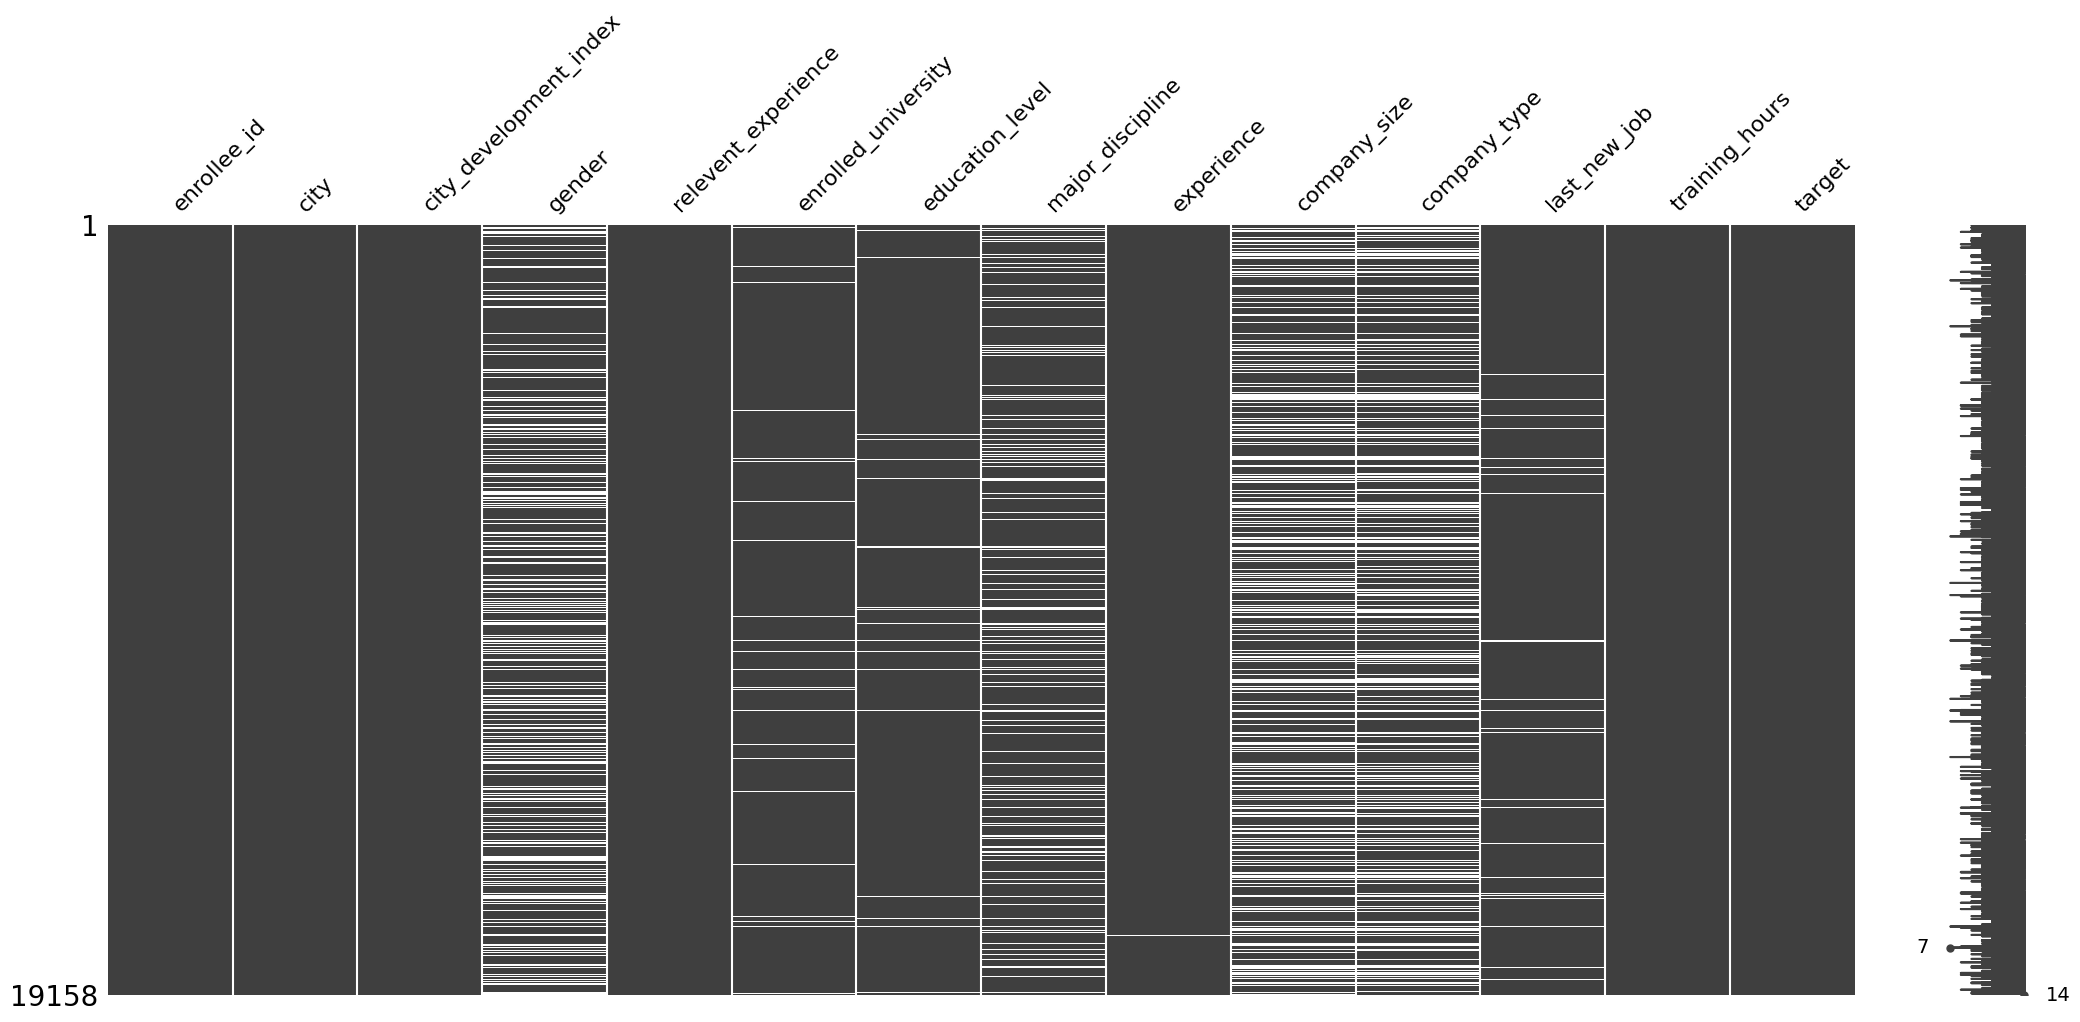

<Figure size 1500x900 with 0 Axes>

In [ ]:
msno.matrix(df)
plt.figure(figsize = (15,9))
plt.show()

<Axes: >

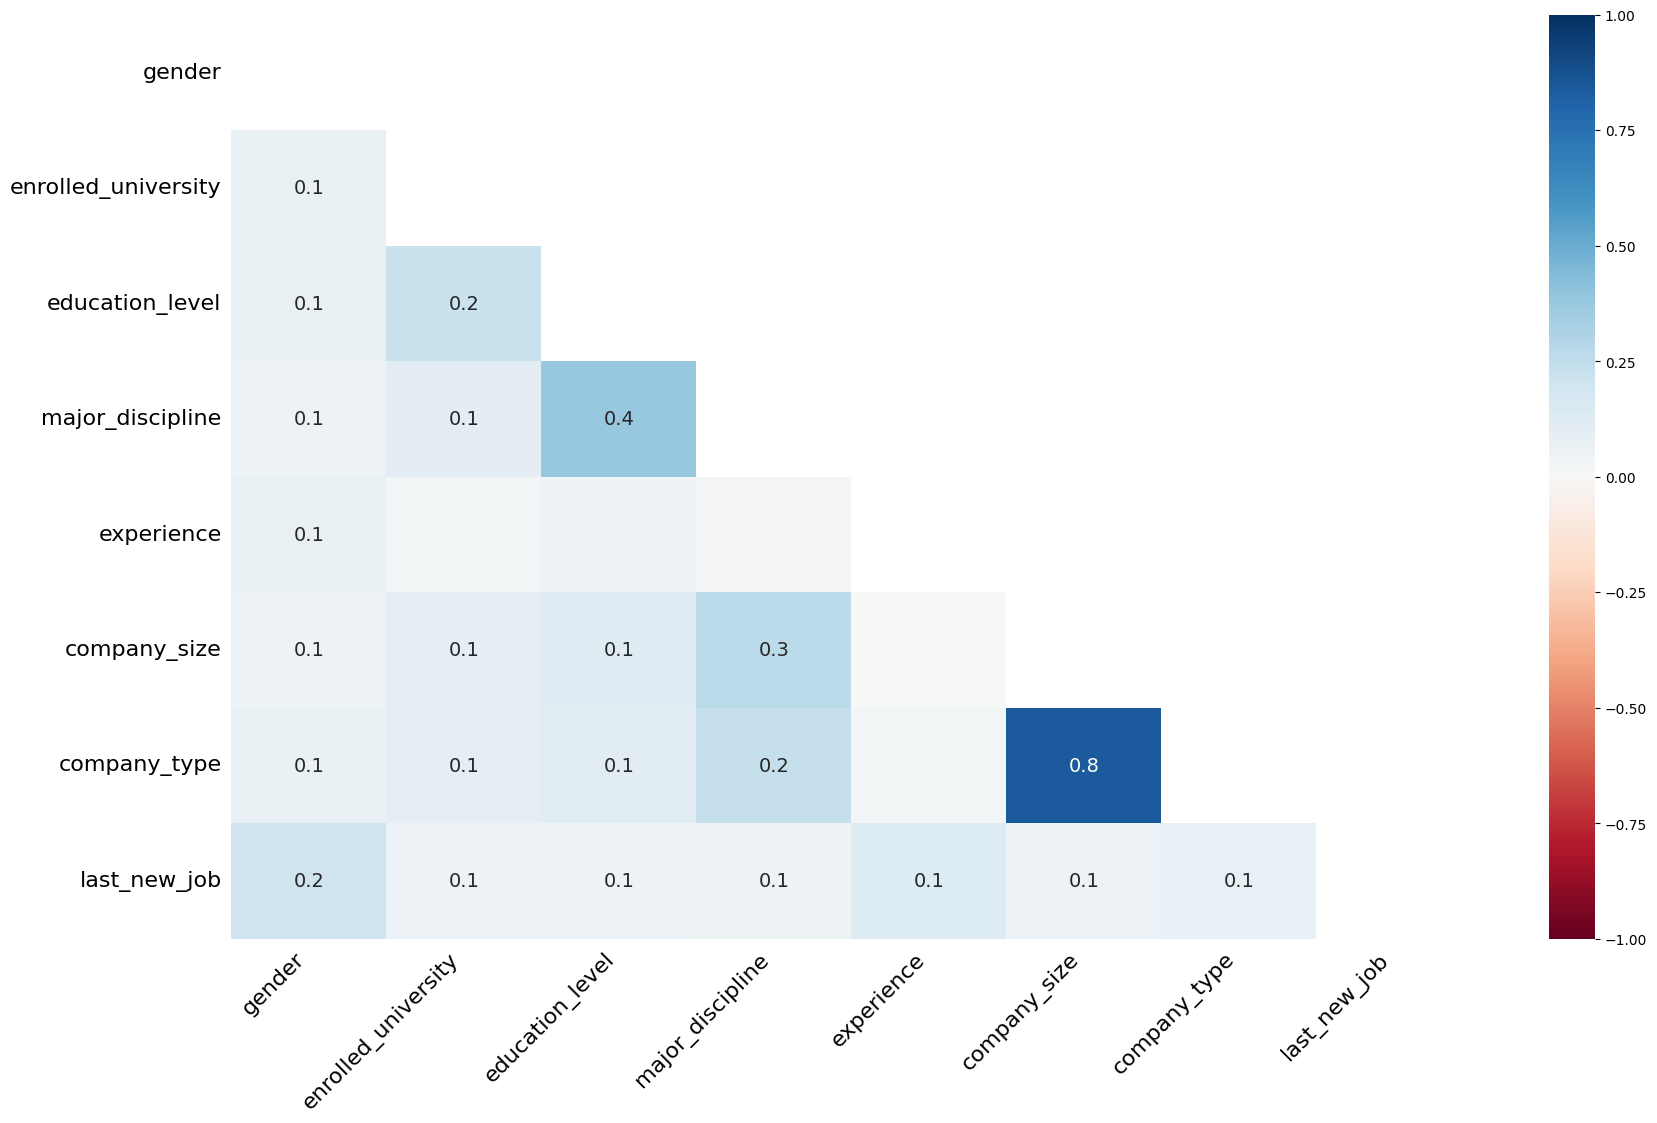

In [ ]:
msno.heatmap(df, labels = True)

Корреляционная тепловая карта измеряет корреляцию пропусков между столбцами набора данных. Она показывает, насколько сильно наличие или отсутствие одного признака влияет на другой.

Корреляция пропусков варьируется от (-1 до 1):

-1 означает, что если один столбец (признак) присутствует, другой почти наверняка отсутствует.

0 означает, что между столбцами (признаками) нет зависимости.

1 означает, что если один столбец (признак) присутствует, другой также обязательно присутствует.

В отличие от привычной корреляционной тепловой карты, здесь вы можете видеть, что многие столбцы отсутствуют. Те столбцы, которые всегда заполнены или всегда пусты, не имеют значимой корреляции и исключены из визуализации.

Тепловая карта полезна для выявления корреляций полноты данных между парами признаков, однако её способность объяснять более широкие взаимосвязи ограничена, и она не имеет специальной поддержки для действительно больших наборов данных.


In [ ]:
# Columns having missing values
missing_columns = [col for col in df.columns if df[col].isnull().sum() > 0]
missing_columns

['gender',
 'enrolled_university',
 'education_level',
 'major_discipline',
 'experience',
 'company_size',
 'company_type',
 'last_new_job']

<Axes: >

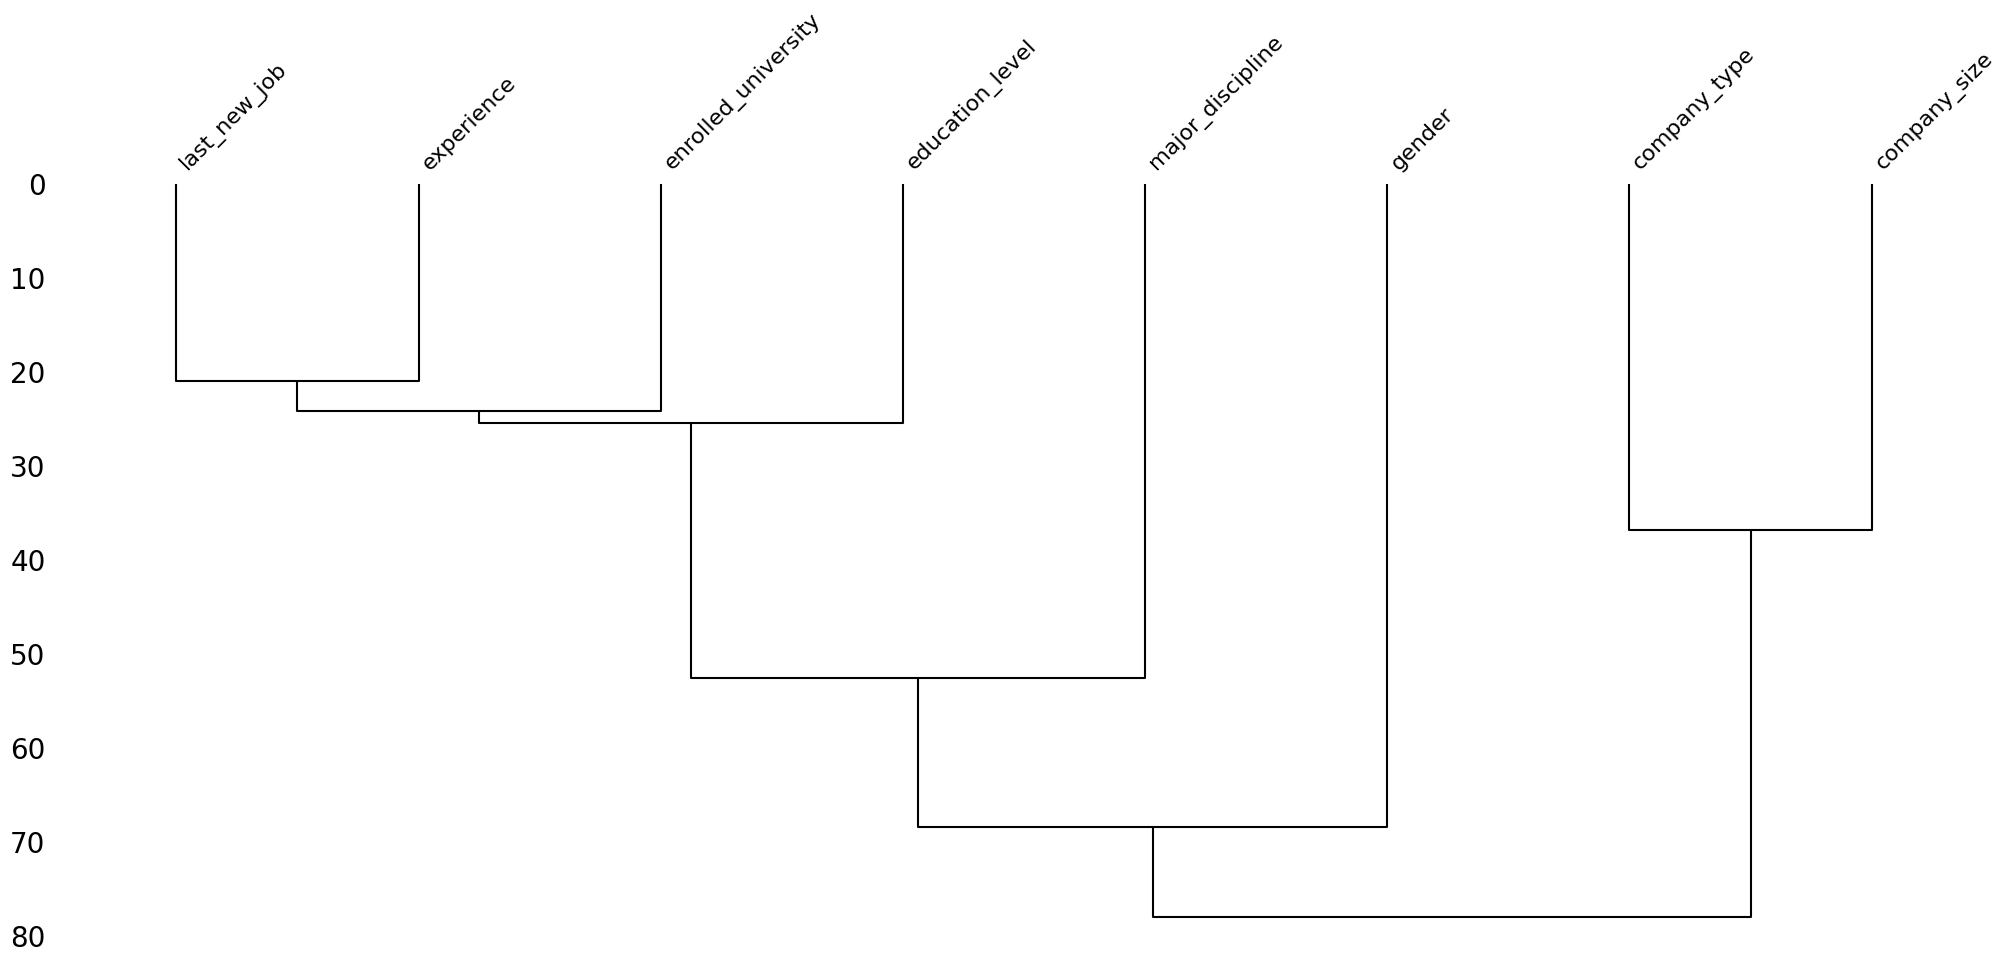

In [ ]:
msno.dendrogram(df[missing_columns])

Дендрограмма показывает иерархические отношения пропусков между столбцами. Дендрограмма использует алгоритм иерархической кластеризации, группируя столбцы на основе их корреляции по пропускам.

[Об иерархической кластенризации](https://)

Интерпретация дендрограммы основана на подходе «сверху вниз», то есть мы фокусируемся на высоте, на которой соединяются любые два столбца — это говорит об их связи по наличию пропусков.

Чем больше высота соединения, тем слабее связь, и наоборот, это утверждение также верно.

Например, если мы видим, что пара признаков last_new_job(Разница в годах между предыдущей и текущей работой) и experience имеет высоту близкую к 0, это означает, что они сильно коррелируют в плане наличия пропусков. Аналогично, признаки last_new_job и genger имеют максимальную высоту соединения, что означает их слабую корреляцию друг с другом.

In [ ]:
def get_numerical_summary(df):
    total = df.shape[0]
    missing_columns = [col for col in df.columns if df[col].isnull().sum() > 0]
    missing_percent = {}
    for col in missing_columns:
        null_count = df[col].isnull().sum()
        per = (null_count/total) * 100
        missing_percent[col] = per
        print("{} : {} ({}%)".format(col, null_count, round(per, 3)))
    return missing_percent

In [ ]:
missing_percent = get_numerical_summary(df)

gender : 4508 (23.531%)
enrolled_university : 386 (2.015%)
education_level : 460 (2.401%)
major_discipline : 2813 (14.683%)
experience : 65 (0.339%)
company_size : 5938 (30.995%)
company_type : 6140 (32.049%)
last_new_job : 423 (2.208%)


Простые числовые сводки

Продолжим, попробуем проанализировать числовую сводку по пропущенным признакам. Простые числовые сводки эффективны для выявления проблемных предикторов и образцов данных, когда набор данных становится слишком большим для визуального изучения.



На основе процента пропусков признаки можно разделить на 3 группы:

* Критические пропуски ( > 20%):

company_type (32.049%)

company_size (30.995%)

gender (23.531%)

major_discipline (14.683%)

Вывод: Это главные проблемные столбцы. Простое удаление этих строк или столбцов приведет к потере значительной части данных. Требуются продуманные стратегии импутации (заполнения) или создания отдельного индикатора пропуска (was_missing).

* Умеренные пропуски (1% - 10%):

last_new_job (2.208%)

education_level (2.401%)

enrolled_university (2.015%)

Вывод: Объем данных для разумной импутации достаточен. Можно использовать статистические методы (мода, медиана) или более сложные (KNN, MICE), не сильно искажая распределение.

* Незначительные пропуски ( < 1%):

experience (0.339%)

Вывод: Самый простой случай. Эти пропуски можно удалить (убрать 65 строк из ~19k почти не повлияет на модель) или заполнить самым простым методом без риска.

In [ ]:
cat_missing_cols = [col for col in missing_columns if df[col].dtype == 'object']
cat_missing_cols

['gender',
 'enrolled_university',
 'education_level',
 'major_discipline',
 'experience',
 'company_size',
 'company_type',
 'last_new_job']

In [ ]:
summary_df = pd.DataFrame()

for col in cat_missing_cols:
    # Статистика по столбцу
    col_stats = {
        'column': col,
        'dtype': str(df[col].dtype),
        'total_count': len(df),
        'missing_count': df[col].isnull().sum(),
        'missing_percent': round(df[col].isnull().sum() / len(df) * 100, 2),
        'unique_values': df[col].nunique(),
        'top_value': df[col].value_counts(dropna=True).index[0] if df[col].notna().any() else 'N/A',
        'top_value_count': df[col].value_counts(dropna=True).iloc[0] if df[col].notna().any() else 0,
        'top_value_percent': round(df[col].value_counts(dropna=True).iloc[0] / df[col].notna().sum() * 100, 2) if df[col].notna().any() else 0
    }
    summary_df = pd.concat([summary_df, pd.DataFrame([col_stats])], ignore_index=True)

print("Сводная информация по категориальным столбцам с пропусками:")
print(summary_df.to_string())

Сводная информация по категориальным столбцам с пропусками:
                column   dtype  total_count  missing_count  missing_percent  unique_values      top_value  top_value_count  top_value_percent
0               gender  object        19158           4508            23.53              3           Male            13221              90.25
1  enrolled_university  object        19158            386             2.01              3  no_enrollment            13817              73.60
2      education_level  object        19158            460             2.40              5       Graduate            11598              62.03
3     major_discipline  object        19158           2813            14.68              6           STEM            14492              88.66
4           experience  object        19158             65             0.34             22            >20             3286              17.21
5         company_size  object        19158           5938            30.99             

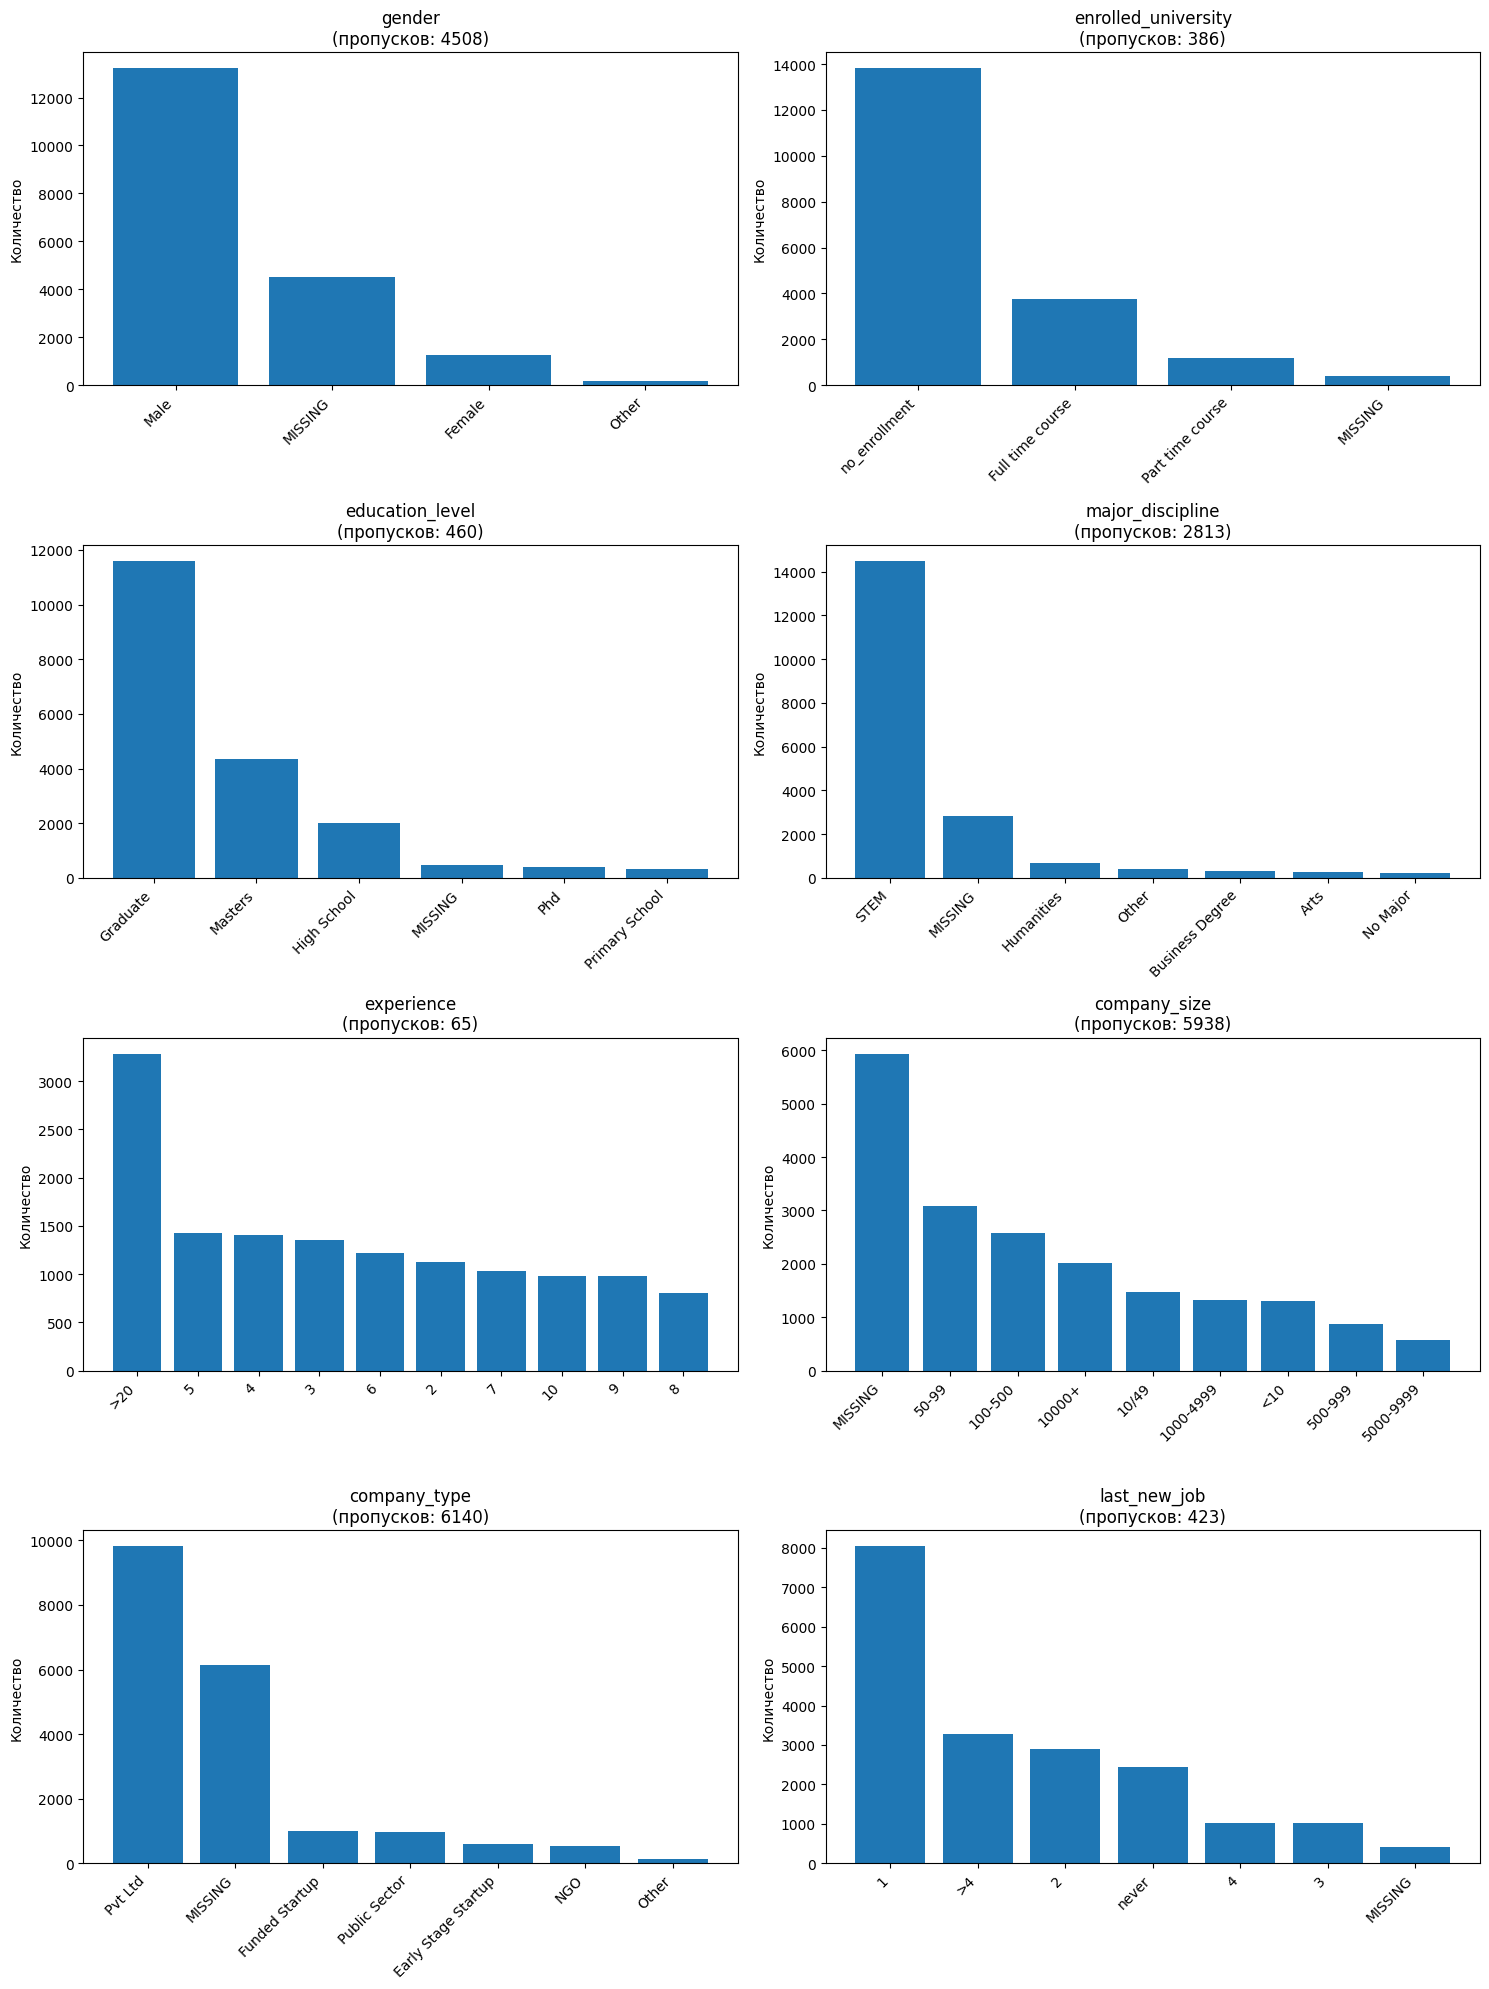

In [ ]:


fig, axes = plt.subplots(4, 2, figsize=(15, 20))
axes = axes.flatten()

for idx, col in enumerate(cat_missing_cols):
    # Создаем копию столбца, где заменяем NaN на строку 'MISSING'
    temp_series = df[col].fillna('MISSING')

    # Получаем value counts
    value_counts = temp_series.value_counts()

    # Строим барплот
    if len(value_counts) > 10:
        # Если значений много, показываем только топ-10
        top_values = value_counts.head(10)
        axes[idx].bar(range(len(top_values)), top_values.values)
        axes[idx].set_xticks(range(len(top_values)))
        axes[idx].set_xticklabels(top_values.index, rotation=45, ha='right')
    else:
        axes[idx].bar(range(len(value_counts)), value_counts.values)
        axes[idx].set_xticks(range(len(value_counts)))
        axes[idx].set_xticklabels(value_counts.index, rotation=45, ha='right')

    axes[idx].set_title(f'{col}\n(пропусков: {df[col].isnull().sum()})')
    axes[idx].set_ylabel('Количество')

plt.tight_layout()
plt.show()

In [ ]:
# Столбцы с незначительными пропусками (<3%)
minor_missing_cols = ['enrolled_university', 'education_level', 'experience', 'last_new_job']

In [ ]:
# Удаляем только experience (самый маленький процент пропусков)
print(f"Удаление пропусков только в 'experience' (0.339%):")
df_exp_clean = df.dropna(subset=['experience'])
print(f"Было: {len(df)}, стало: {len(df_exp_clean)}")
print(f"Удалено: {len(df) - len(df_exp_clean)} строк")

# # Проверяем, как это повлияло на другие пропуски
# print("\nОставшиеся пропуски после удаления experience:")
# for col in minor_missing_cols:
#     if col != 'experience':
#         count = df_exp_clean[col].isnull().sum()
#         percent = count / len(df_exp_clean) * 100
#         print(f"  {col}: {count} ({percent:.3f}%)")


Удаление пропусков только в 'experience' (0.339%):
Было: 19158, стало: 19093
Удалено: 65 строк

Оставшиеся пропуски после удаления experience:
  enrolled_university: 381 (1.995%)
  education_level: 450 (2.357%)
  last_new_job: 399 (2.090%)


In [ ]:
# Проверяем, как это повлияло на другие пропуски
print("\nОставшиеся пропуски после удаления experience:")
for col in missing_columns:
    if col != 'experience':
        count = df_exp_clean[col].isnull().sum()
        percent = count / len(df_exp_clean) * 100
        print(f"  {col}: {count} ({percent:.3f}%)")


Оставшиеся пропуски после удаления experience:
  gender: 4459 (23.354%)
  enrolled_university: 381 (1.995%)
  education_level: 450 (2.357%)
  major_discipline: 2796 (14.644%)
  company_size: 5915 (30.980%)
  company_type: 6104 (31.970%)
  last_new_job: 399 (2.090%)


In [ ]:
print(f"Удаление пропусков только в 'enrolled_university' (1.995%):")
df_exp_clean = df.dropna(subset=['enrolled_university'])
print(f"Было: {len(df)}, стало: {len(df_exp_clean)}")
print(f"Удалено: {len(df) - len(df_exp_clean)} строк")

Удаление пропусков только в 'enrolled_university' (1.995%):
Было: 19158, стало: 18772
Удалено: 386 строк


In [ ]:
# Проверяем, как это повлияло на другие пропуски
print("\nОставшиеся пропуски после удаления enrolled_university:")
for col in missing_columns:
    if col != 'enrolled_university':
        count = df_exp_clean[col].isnull().sum()
        percent = count / len(df_exp_clean) * 100
        print(f"  {col}: {count} ({percent:.3f}%)")


Оставшиеся пропуски после удаления enrolled_university:
  gender: 4335 (23.093%)
  education_level: 360 (1.918%)
  major_discipline: 2656 (14.149%)
  experience: 60 (0.320%)
  company_size: 5701 (30.370%)
  company_type: 5898 (31.419%)
  last_new_job: 390 (2.078%)


In [ ]:
df_exp_clean.isnull().sum()

,0
enrollee_id,0
city,0
city_development_index,0
gender,4335
relevent_experience,0
enrolled_university,0
education_level,360
major_discipline,2656
experience,60
company_size,5701


In [ ]:
# Определяем столбцы для заполнения модой
mode_cols = ['gender', 'education_level', 'last_new_job']

print("Мода для каждого столбца:")
print("=" * 40)

for col in mode_cols:
    mode_value = df[col].mode()[0]  # Берем первую моду (может быть несколько)
    missing_count = df[col].isnull().sum()
    print(f"{col}:")
    print(f"  Мода: '{mode_value}'")
    print(f"  Распределение до заполнения:")
    print(df[col].value_counts(dropna=False).head())
    print(f"  Пропусков до: {missing_count}")

    # Заполняем модой
    df[col] = df[col].fillna(mode_value)

    print(f"  Пропусков после: {df[col].isnull().sum()}")
    print("-" * 30)

Мода для каждого столбца:
gender:
  Мода: 'Male'
  Распределение до заполнения:
gender
Male      13221
NaN        4508
Female     1238
Other       191
Name: count, dtype: int64
  Пропусков до: 4508
  Пропусков после: 0
------------------------------
education_level:
  Мода: 'Graduate'
  Распределение до заполнения:
education_level
Graduate       11598
Masters         4361
High School     2017
NaN              460
Phd              414
Name: count, dtype: int64
  Пропусков до: 460
  Пропусков после: 0
------------------------------
last_new_job:
  Мода: '1'
  Распределение до заполнения:
last_new_job
1        8040
>4       3290
2        2900
never    2452
4        1029
Name: count, dtype: int64
  Пропусков до: 423
  Пропусков после: 0
------------------------------


In [ ]:
# Удаляем строки с пропусками в experience
df.dropna(subset=['experience'], inplace=True)

In [ ]:
# Удаляем строки с пропусками в enrolled_university
df.dropna(subset=['enrolled_university'], inplace=True)

In [ ]:
#Для major_discipline (14.7%) — заполнить категорией "Other"
# Заполняем пропуски категорией "Other"
df['major_discipline'] = df['major_discipline'].fillna('Other')

In [ ]:
df['company_type'].unique()

array([nan, 'Pvt Ltd', 'Funded Startup', 'Early Stage Startup', 'Other',
       'Public Sector', 'NGO'], dtype=object)

In [ ]:
df['company_size'].unique()

array([nan, '50-99', '<10', '10000+', '5000-9999', '1000-4999', '10/49',
       '100-500', '500-999'], dtype=object)

In [ ]:
# Заполняем пропуски 'company_type' значением "Unknown"
df['company_type'] = df['company_type'].fillna('Unknown')

In [ ]:
#Согласованное заполнение с company_type
df['company_size'] = df['company_size'].fillna('Unknown')

In [ ]:
df.isnull().sum()

,0
enrollee_id,0
city,0
city_development_index,0
gender,0
relevent_experience,0
enrolled_university,0
education_level,0
major_discipline,0
experience,0
company_size,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18712 entries, 0 to 19157
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   enrollee_id             18712 non-null  int64  
 1   city                    18712 non-null  object 
 2   city_development_index  18712 non-null  float64
 3   gender                  18712 non-null  object 
 4   relevent_experience     18712 non-null  object 
 5   enrolled_university     18712 non-null  object 
 6   education_level         18712 non-null  object 
 7   major_discipline        18712 non-null  object 
 8   experience              18712 non-null  object 
 9   company_size            18712 non-null  object 
 10  company_type            18712 non-null  object 
 11  last_new_job            18712 non-null  object 
 12  training_hours          18712 non-null  int64  
 13  target                  18712 non-null  float64
dtypes: float64(2), int64(2), object(10)
memory 

In [ ]:
df.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,Unknown,Unknown,1,36,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0.0
2,11561,city_21,0.624,Male,No relevent experience,Full time course,Graduate,STEM,5,Unknown,Unknown,never,83,0.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0.0
5,21651,city_176,0.764,Male,Has relevent experience,Part time course,Graduate,STEM,11,Unknown,Unknown,1,24,1.0


In [ ]:
df.tail()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
19153,7386,city_173,0.878,Male,No relevent experience,no_enrollment,Graduate,Humanities,14,Unknown,Unknown,1,42,1.0
19154,31398,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,14,Unknown,Unknown,4,52,1.0
19155,24576,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,50-99,Pvt Ltd,4,44,0.0
19156,5756,city_65,0.802,Male,Has relevent experience,no_enrollment,High School,Other,<1,500-999,Pvt Ltd,2,97,0.0
19157,23834,city_67,0.855,Male,No relevent experience,no_enrollment,Primary School,Other,2,Unknown,Unknown,1,127,0.0


In [ ]:
# Убираем "city_" и оставляем только число
df['city'] = df['city'].str.replace('city_', '', regex=False)
print("Пример после замены:")
print(df['city'].head())

Пример после замены:
0    103
1     40
2     21
4    162
5    176
Name: city, dtype: object


In [ ]:
df['city'].head()

,city
0,103
1,40
2,21
4,162
5,176


In [ ]:
df['city'] = df['city'].astype('int64')

In [ ]:
# Удаляем столбец enrollee_id
df = df.drop('enrollee_id', axis=1)

In [ ]:
df['gender'].unique() #OHE

array(['Male', 'Female', 'Other'], dtype=object)

In [ ]:
df['relevent_experience'].unique() #OHE

array(['Has relevent experience', 'No relevent experience'], dtype=object)

In [ ]:
df['enrolled_university'].unique() #OHE

array(['no_enrollment', 'Full time course', 'Part time course'],
      dtype=object)

In [ ]:
df['education_level'].unique() #Label

array(['Graduate', 'Masters', 'High School', 'Phd', 'Primary School'],
      dtype=object)

In [ ]:
df['major_discipline'].unique() #OHE

array(['STEM', 'Other', 'Arts', 'Humanities', 'Business Degree',
       'No Major'], dtype=object)

In [ ]:
df['experience'].unique()

array(['25', '15', '5', '11', '13', '7', '17', '2', '16', '1', '4', '10',
       '0.5', '14', '18', '19', '12', '3', '6', '9', '8', '20'],
      dtype=object)

In [ ]:
# Производим замену
df['experience'] = df['experience'].replace('>20', '25')
df['experience'] = df['experience'].replace('<1', '0.5')

In [ ]:
df['experience'] = df['experience'].astype('float64')

In [ ]:
df['company_size'].unique() #Ordinal Encoding

array(['Unknown', '50-99', '<10', '10000+', '5000-9999', '1000-4999',
       '10/49', '100-500', '500-999'], dtype=object)

In [ ]:
size_order = ['Unknown', '<10', '10/49', '50-99', '100-500',
              '500-999', '1000-4999', '5000-9999', '10000+']
size_mapping = {size: i for i, size in enumerate(size_order)}

df['company_size_encoded'] = df['company_size'].map(size_mapping)


In [ ]:
df

,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target,company_size_encoded
0,103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,25.0,Unknown,Other,1,36,1.0,0
1,40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15.0,50-99,Pvt Ltd,>4,47,0.0,3
2,21,0.624,Male,No relevent experience,Full time course,Graduate,STEM,5.0,Unknown,Other,never,83,0.0,0
4,162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,25.0,50-99,Funded Startup,4,8,0.0,3
5,176,0.764,Male,Has relevent experience,Part time course,Graduate,STEM,11.0,Unknown,Other,1,24,1.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19153,173,0.878,Male,No relevent experience,no_enrollment,Graduate,Humanities,14.0,Unknown,Other,1,42,1.0,0
19154,103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,14.0,Unknown,Other,4,52,1.0,0
19155,103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,25.0,50-99,Pvt Ltd,4,44,0.0,3
19156,65,0.802,Male,Has relevent experience,no_enrollment,High School,Other,0.5,500-999,Pvt Ltd,2,97,0.0,5


In [ ]:
df = df.drop('company_size', axis=1)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18712 entries, 0 to 19157
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   city                    18712 non-null  int64  
 1   city_development_index  18712 non-null  float64
 2   gender                  18712 non-null  object 
 3   relevent_experience     18712 non-null  object 
 4   enrolled_university     18712 non-null  object 
 5   education_level         18712 non-null  object 
 6   major_discipline        18712 non-null  object 
 7   experience              18712 non-null  float64
 8   company_type            18712 non-null  object 
 9   last_new_job            18712 non-null  object 
 10  training_hours          18712 non-null  int64  
 11  target                  18712 non-null  float64
 12  company_size_encoded    18712 non-null  int64  
dtypes: float64(3), int64(3), object(7)
memory usage: 2.0+ MB


In [ ]:
df['company_type'].unique()

array(['Unknown', 'Pvt Ltd', 'Funded Startup', 'Early Stage Startup',
       'Other', 'Public Sector', 'NGO'], dtype=object)

In [ ]:
# Производим замену
df['company_type'] = df['company_type'].replace('Unknown', 'Other')


In [ ]:
df['company_type'].unique() #OHE

array(['Other', 'Pvt Ltd', 'Funded Startup', 'Early Stage Startup',
       'Public Sector', 'NGO'], dtype=object)

In [ ]:
df['last_new_job'].unique() #Ordinal Encoding

array(['1', '>4', 'never', '4', '3', '2'], dtype=object)

In [ ]:
job_change_order = ['never', '>4', '4', '3', '2', '1']
job_mapping = {value: i for i, value in enumerate(job_change_order)}

df['last_new_job_encoded'] = df['last_new_job'].map(job_mapping)


In [ ]:
df

,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_type,last_new_job,training_hours,target,company_size_encoded,last_new_job_encoded
0,103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,25.0,Other,1,36,1.0,0,5
1,40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15.0,Pvt Ltd,>4,47,0.0,3,1
2,21,0.624,Male,No relevent experience,Full time course,Graduate,STEM,5.0,Other,never,83,0.0,0,0
4,162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,25.0,Funded Startup,4,8,0.0,3,2
5,176,0.764,Male,Has relevent experience,Part time course,Graduate,STEM,11.0,Other,1,24,1.0,0,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19153,173,0.878,Male,No relevent experience,no_enrollment,Graduate,Humanities,14.0,Other,1,42,1.0,0,5
19154,103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,14.0,Other,4,52,1.0,0,2
19155,103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,25.0,Pvt Ltd,4,44,0.0,3,2
19156,65,0.802,Male,Has relevent experience,no_enrollment,High School,Other,0.5,Pvt Ltd,2,97,0.0,5,4


In [ ]:
 df = df.drop('last_new_job', axis=1)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18712 entries, 0 to 19157
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   city                    18712 non-null  int64  
 1   city_development_index  18712 non-null  float64
 2   gender                  18712 non-null  object 
 3   relevent_experience     18712 non-null  object 
 4   enrolled_university     18712 non-null  object 
 5   education_level         18712 non-null  object 
 6   major_discipline        18712 non-null  object 
 7   experience              18712 non-null  float64
 8   company_type            18712 non-null  object 
 9   training_hours          18712 non-null  int64  
 10  target                  18712 non-null  float64
 11  company_size_encoded    18712 non-null  int64  
 12  last_new_job_encoded    18712 non-null  int64  
dtypes: float64(3), int64(4), object(6)
memory usage: 2.0+ MB


In [ ]:
# Столбцы для One-Hot Encoding
onehot_columns = ['company_type', 'major_discipline', 'enrolled_university',
                  'relevent_experience', 'gender']


In [ ]:
# Столбцы для Label Encoding
label_columns = ['education_level']

In [ ]:
# Применяем One-Hot Encoding
df_encoded = pd.get_dummies(
    df,
    columns=onehot_columns,  # передаем список столбцов
    prefix=onehot_columns,    # префиксы для каждого столбца
    dtype=int,                # тип данных
    drop_first=False          # не удаляем первую категорию (dummy variable trap)
)

In [ ]:
df_encoded = pd.concat([df_encoded, dummies], axis=1)

,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_type,training_hours,target,company_size_encoded,last_new_job_encoded
0,103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,25.0,Other,36,1.0,0,5
1,40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15.0,Pvt Ltd,47,0.0,3,1
2,21,0.624,Male,No relevent experience,Full time course,Graduate,STEM,5.0,Other,83,0.0,0,0
4,162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,25.0,Funded Startup,8,0.0,3,2
5,176,0.764,Male,Has relevent experience,Part time course,Graduate,STEM,11.0,Other,24,1.0,0,5


In [ ]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18712 entries, 0 to 19157
Data columns (total 28 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   city                                         18712 non-null  int64  
 1   city_development_index                       18712 non-null  float64
 2   education_level                              18712 non-null  object 
 3   experience                                   18712 non-null  float64
 4   training_hours                               18712 non-null  int64  
 5   target                                       18712 non-null  float64
 6   company_size_encoded                         18712 non-null  int64  
 7   last_new_job_encoded                         18712 non-null  int64  
 8   company_type_Early Stage Startup             18712 non-null  int64  
 9   company_type_Funded Startup                  18712 non-null  int64  
 10  com

In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
 le = LabelEncoder()

In [ ]:
df_encoded['education_level'] = le.fit_transform(df_encoded['education_level'])

In [ ]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18712 entries, 0 to 19157
Data columns (total 28 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   city                                         18712 non-null  int64  
 1   city_development_index                       18712 non-null  float64
 2   education_level                              18712 non-null  int64  
 3   experience                                   18712 non-null  float64
 4   training_hours                               18712 non-null  int64  
 5   target                                       18712 non-null  float64
 6   company_size_encoded                         18712 non-null  int64  
 7   last_new_job_encoded                         18712 non-null  int64  
 8   company_type_Early Stage Startup             18712 non-null  int64  
 9   company_type_Funded Startup                  18712 non-null  int64  
 10  com

In [ ]:
df_encoded['target'].unique()

array([1., 0.])


BOX PLOT ДЛЯ ВЫЯВЛЕНИЯ ВЫБРОСОВ:


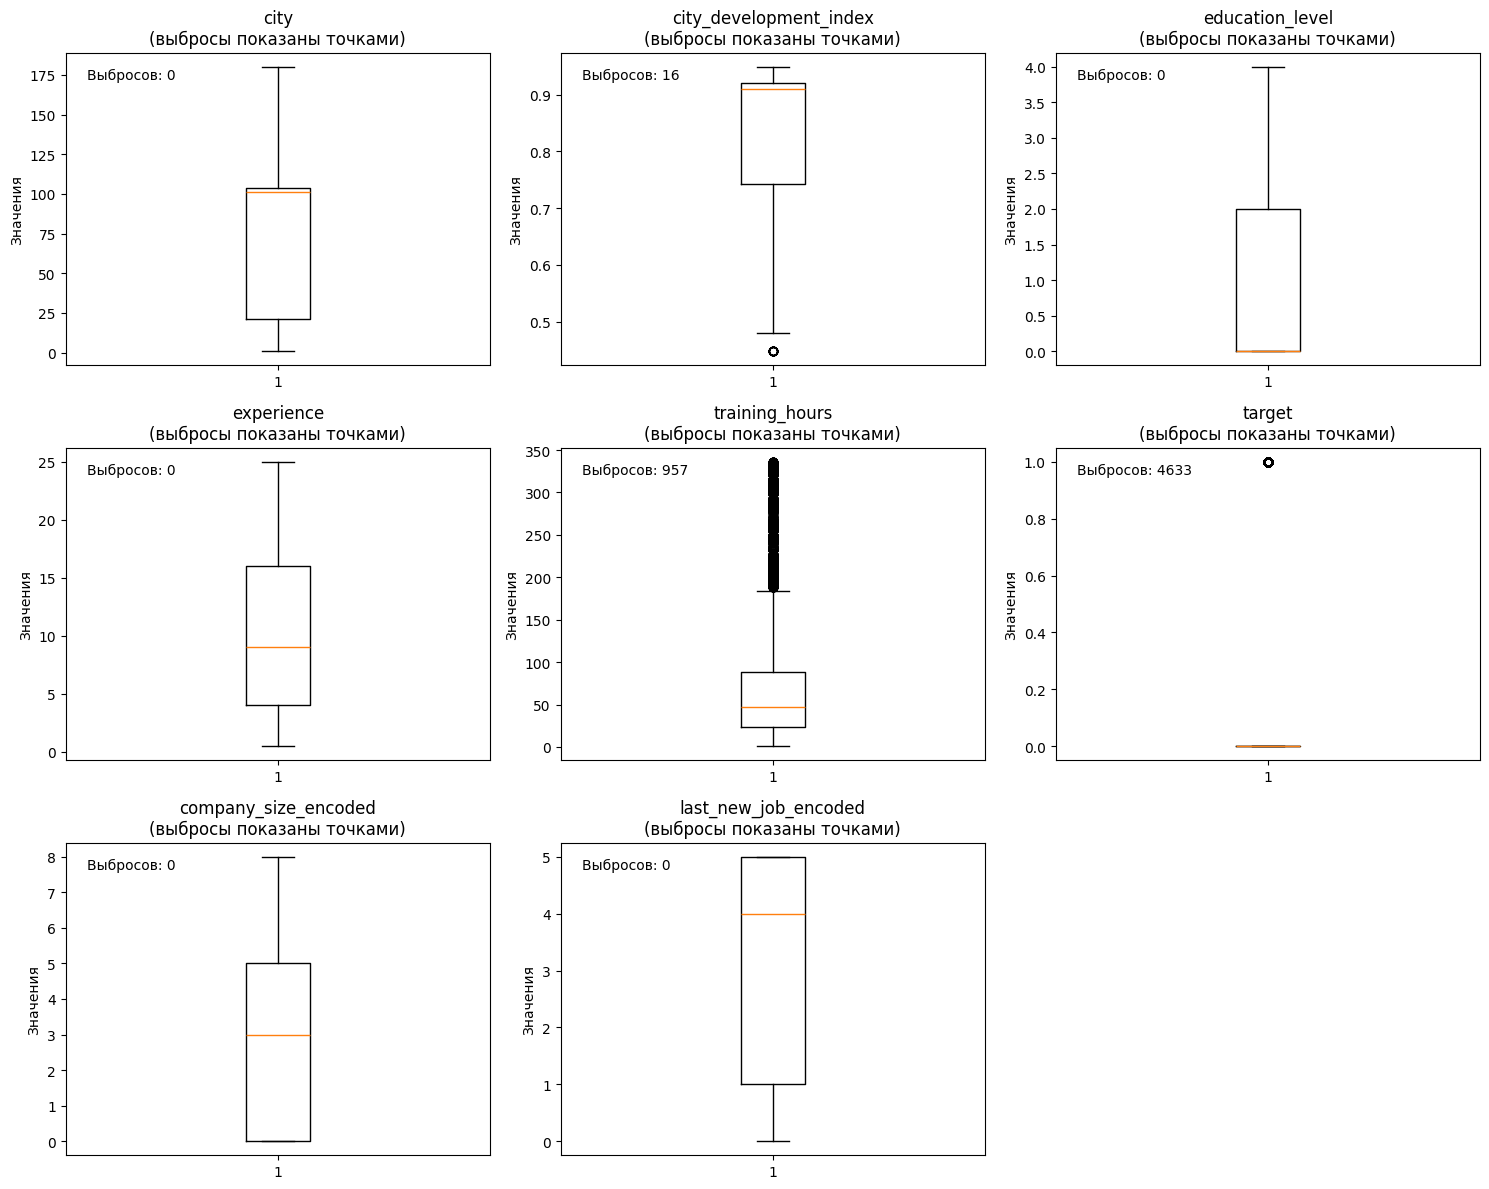

In [ ]:
import seaborn as sns

print("\nBOX PLOT ДЛЯ ВЫЯВЛЕНИЯ ВЫБРОСОВ:")
print("=" * 70)

# Выбираем числовые столбцы для анализа
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

if numeric_cols:
    # Ограничиваем количество графиков
    cols_to_plot = numeric_cols[:8] if len(numeric_cols) > 8 else numeric_cols

    # Создаем subplot
    n_cols = min(3, len(cols_to_plot))
    n_rows = (len(cols_to_plot) + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
    axes = axes.flatten() if len(cols_to_plot) > 1 else [axes]

    for idx, col in enumerate(cols_to_plot):
        axes[idx].boxplot(df[col].dropna())
        axes[idx].set_title(f'{col}\n(выбросы показаны точками)')
        axes[idx].set_ylabel('Значения')

        # Добавляем статистику на график
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr

        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]
        axes[idx].text(0.05, 0.95, f'Выбросов: {len(outliers)}',
                      transform=axes[idx].transAxes, verticalalignment='top')

    # Скрываем пустые subplots
    for idx in range(len(cols_to_plot), len(axes)):
        axes[idx].set_visible(False)

    plt.tight_layout()
    plt.show()
else:
    print("Нет числовых столбцов для построения box plot")

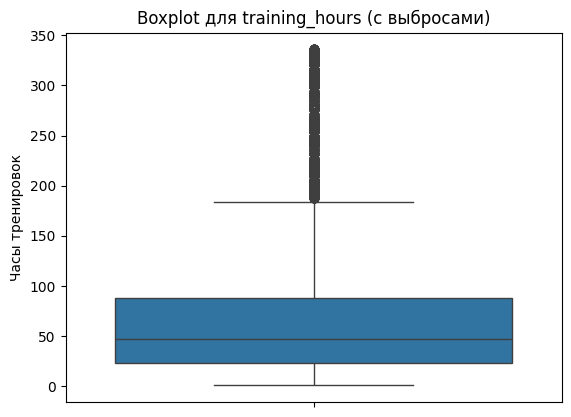

In [ ]:
sns.boxplot(y=df_encoded['training_hours'])

plt.title("Boxplot для training_hours (с выбросами)")
plt.ylabel("Часы тренировок")

# Отображаем график
plt.show()

Это не выбросы а просто значения, поэтому не удалаю



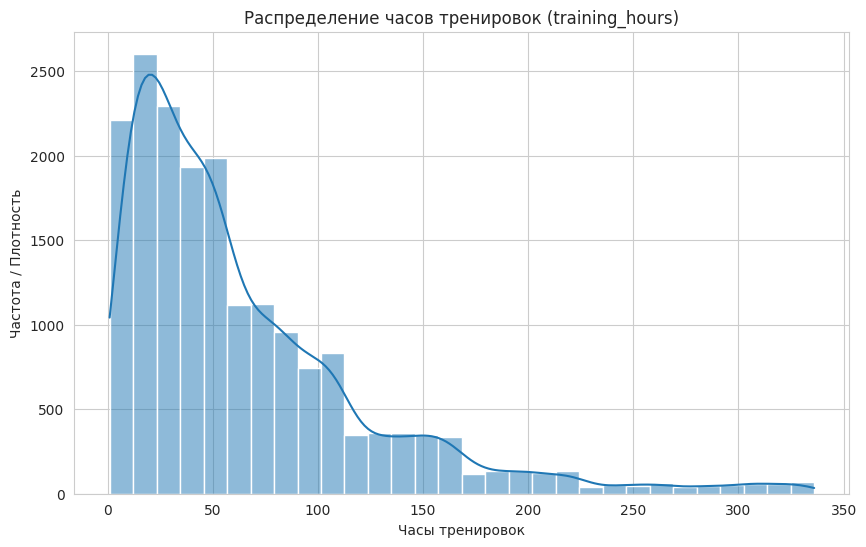

In [ ]:
# Установите стиль для лучшей читаемости (опционально)
sns.set_style("whitegrid")

# Построение гистограммы с наложением кривой плотности
plt.figure(figsize=(10, 6)) # Устанавливаем размер графика
sns.histplot(data=df_encoded, x='training_hours', kde=True, bins=30)
# bins=30 задает количество столбиков на гистограмме

plt.title("Распределение часов тренировок (training_hours)")
plt.xlabel("Часы тренировок")
plt.ylabel("Частота / Плотность")

plt.show()

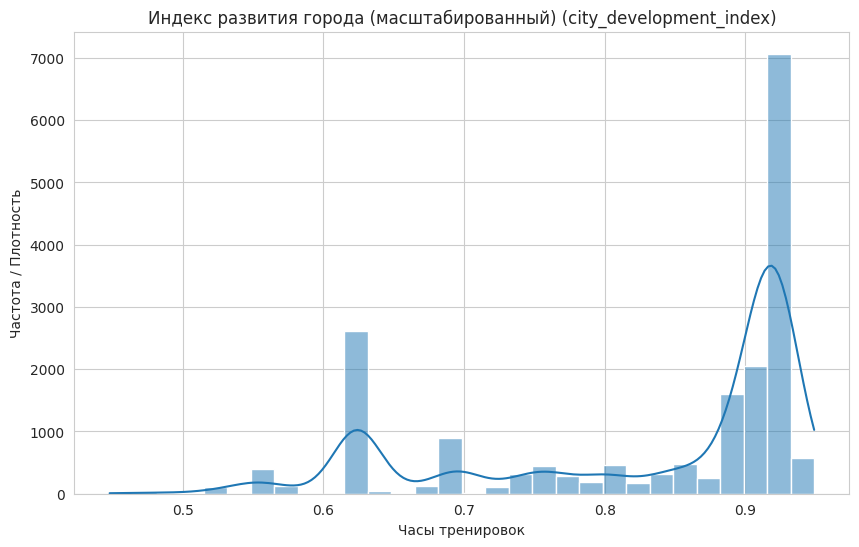

In [ ]:
# Установите стиль для лучшей читаемости (опционально)
sns.set_style("whitegrid")

# Построение гистограммы с наложением кривой плотности
plt.figure(figsize=(10, 6)) # Устанавливаем размер графика
sns.histplot(data=df_encoded, x='city_development_index', kde=True, bins=30)
# bins=30 задает количество столбиков на гистограмме

plt.title("Индекс развития города (масштабированный) (city_development_index)")
plt.xlabel("Часы тренировок")
plt.ylabel("Частота / Плотность")

plt.show()

In [ ]:
# Вычисляем корреляционную матрицу
corr_matrix = df_encoded.corr()

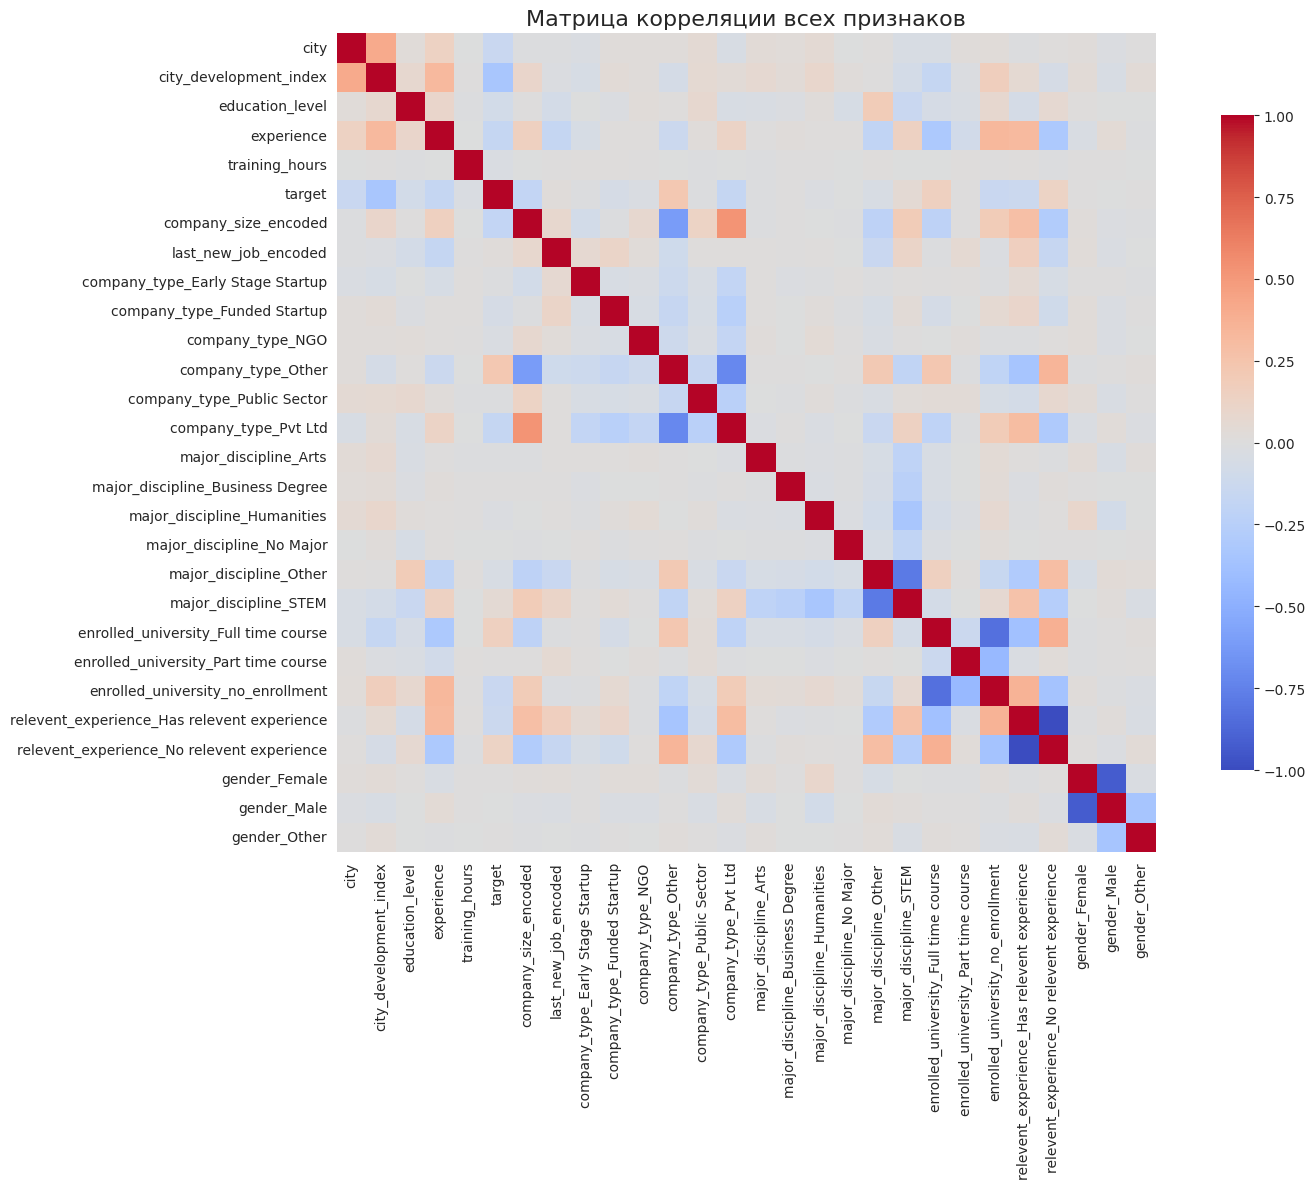

In [ ]:
plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix,
            cmap='coolwarm',
            center=0,
            annot=False,  # если хотите числа в ячейках - поставьте True
            square=True,
            cbar_kws={'shrink': 0.8})
plt.title('Матрица корреляции всех признаков', fontsize=16)
plt.tight_layout()
plt.show()

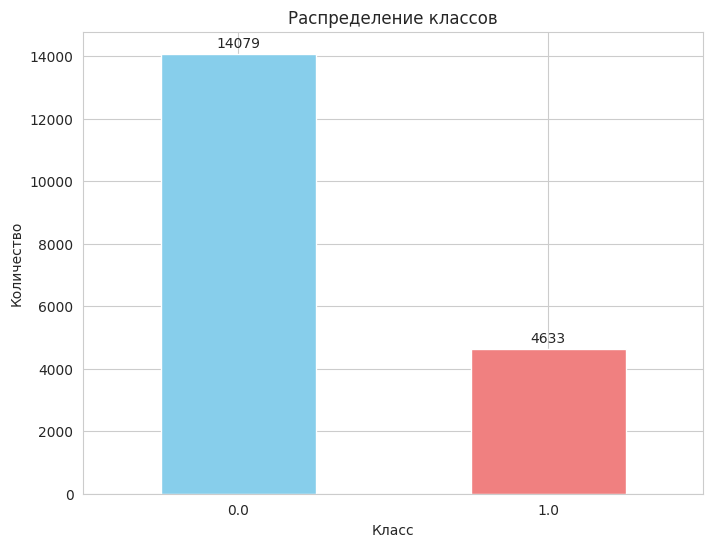

In [ ]:
plt.figure(figsize=(8, 6))
ax = df_encoded['target'].value_counts().plot(kind='bar', color=['skyblue', 'lightcoral'])
plt.title('Распределение классов')
plt.xlabel('Класс')
plt.ylabel('Количество')
plt.xticks(rotation=0)

# Добавляем подписи значений на столбцах
for i in ax.patches:
    ax.text(i.get_x() + i.get_width()/2, i.get_height() + 100,
            str(int(i.get_height())),
            ha='center', va='bottom')
plt.show()

Данные несбалансированны

In [ ]:
# Подготовка данных
X = df_encoded.drop('target', axis=1)
y = df_encoded['target']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
# 2. Затем нормализуем ТОЛЬКО обучающие данные
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# 3. Тестовые данные преобразуем с теми же параметрами
X_test_scaled = scaler.transform(X_test)

**1 модель**

================================================================================
МОДЕЛЬ 1: БАЗОВАЯ АРХИТЕКТУРА
================================================================================
Архитектура: 20-10-1, ReLU, Adam, 20 эпох

In [ ]:
# Создаем нейронную сеть
n_features = X_train_scaled.shape[1]

model = Sequential()
model.add(Dense(20, activation='relu', input_shape=(n_features,)))
model.add(Dense(10, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Компилируем модель
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])


In [ ]:
# Обучение модели
history = model.fit(X_train_scaled, y_train,
                    epochs=20,
                    batch_size=32,
                    verbose=1,
                    validation_data=(X_test_scaled, y_test))

Epoch 1/20
468/468 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.7329 - loss: 0.5512 - val_accuracy: 0.7686 - val_loss: 0.4852
Epoch 2/20
468/468 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7770 - loss: 0.4662 - val_accuracy: 0.7756 - val_loss: 0.4740
Epoch 3/20
468/468 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7824 - loss: 0.4492 - val_accuracy: 0.7764 - val_loss: 0.4665
Epoch 4/20
468/468 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7856 - loss: 0.4469 - val_accuracy: 0.7726 - val_loss: 0.4673
Epoch 5/20
468/468 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7785 - loss: 0.4500 - val_accuracy: 0.7748 - val_loss: 0.4670
Epoch 6/20
468/468 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7887 - loss: 0.4430 - val_accuracy: 0.7772 - val_loss: 0.4643
Epoch 7/20
468/468 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7837 - loss: 0.4476 - val_accuracy: 0.7780 - val_loss: 0.4646
Epoch 8/20
468/468 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7925 - loss: 0.4360 - val_accuracy: 0.

In [ ]:
# Прогноз и оценка
y_pred_prob = model.predict(X_test_scaled)
y_pred = (y_pred_prob > 0.5).astype(int)

117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [ ]:
# Метрики
accuracy = accuracy_score(y_test, y_pred)

print(f"\nAccuracy на тестовой выборке: {accuracy:.4f}")



Accuracy на тестовой выборке: 0.7788


In [ ]:
# Оценка
metrics1 = evaluate_model(model, X_test_scaled, y_test, "Модель 1 (Базовая)")

Accuracy: 0.7788
Precision: 0.5635
Recall: 0.4736
F1-Score: 0.5147

Отчет по классификации для Модель 1 (Базовая):
              precision    recall  f1-score   support

     Class 0       0.84      0.88      0.86      2816
     Class 1       0.56      0.47      0.51       927

    accuracy                           0.78      3743
   macro avg       0.70      0.68      0.69      3743
weighted avg       0.77      0.78      0.77      3743



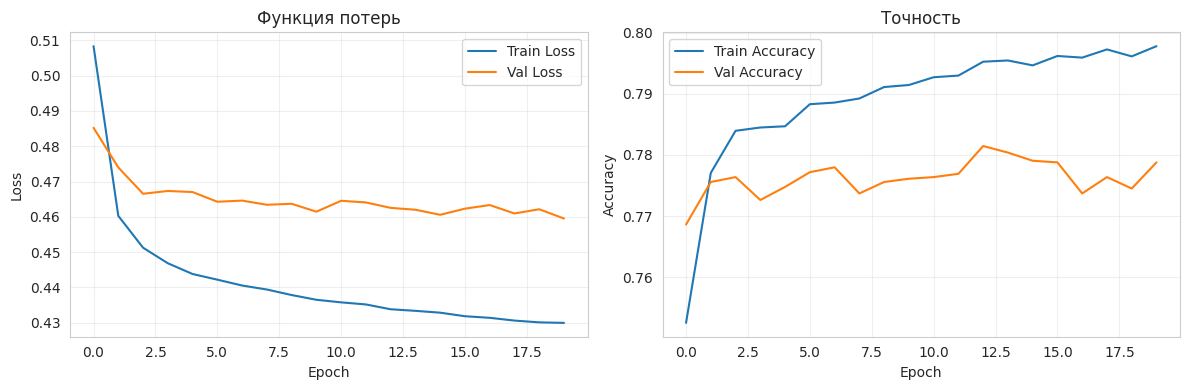

In [ ]:
# Визуализация обучения
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Функция потерь')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Точность')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Для кросс-валидации создаем функцию
def train_with_cross_validation(X, y, n_splits=5):
    kfold = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    scores = []

    for fold, (train_ix, test_ix) in enumerate(kfold.split(X, y)):
        # Разделение
        X_train_fold = X.iloc[train_ix]
        X_test_fold = X.iloc[test_ix]
        y_train_fold = y.iloc[train_ix]
        y_test_fold = y.iloc[test_ix]

        # Нормализация КАЖДОГО фолда (ваш подход)
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train_fold)
        X_test_scaled = scaler.transform(X_test_fold)

        # Создание модели
        n_features = X_train_scaled.shape[1]
        model = Sequential()
        model.add(Dense(20, activation='relu', input_shape=(n_features,)))
        model.add(Dense(10, activation='relu'))
        model.add(Dense(1, activation='sigmoid'))

        model.compile(optimizer='adam',
                      loss='binary_crossentropy',
                      metrics=['accuracy'])

        # Обучение
        model.fit(X_train_scaled, y_train_fold,
                  epochs=20,
                  batch_size=32,
                  verbose=0)

        # Прогноз и оценка
        y_pred_prob = model.predict(X_test_scaled)
        y_pred = (y_pred_prob > 0.5).astype(int)
        score = accuracy_score(y_test_fold, y_pred)
        scores.append(score)

        print(f"Фолд {fold+1}: Accuracy = {score:.4f}")

    return scores


In [ ]:
# Запускаем кросс-валидацию
print("Кросс-валидация (5 фолдов):")
cv_scores = train_with_cross_validation(X, y, n_splits=5)

print(f"\nСредняя точность: {np.mean(cv_scores):.4f}")
print(f"Стандартное отклонение: {np.std(cv_scores):.4f}")
print(f"Лучшая точность: {np.max(cv_scores):.4f}")
print(f"Худшая точность: {np.min(cv_scores):.4f}")

Кросс-валидация (5 фолдов):


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Фолд 1: Accuracy = 0.7844


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Фолд 2: Accuracy = 0.7812


...

117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Фолд 3: Accuracy = 0.7771


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Фолд 4: Accuracy = 0.7830


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Фолд 5: Accuracy = 0.7819

Средняя точность: 0.7815
Стандартное отклонение: 0.0025
Лучшая точность: 0.7844
Худшая точность: 0.7771


In [ ]:
def evaluate_model(model, X_test_scaled, y_test, model_name=""):
    """Оценка модели и вывод метрик"""
    y_pred_prob = model.predict(X_test_scaled, verbose=0)
    y_pred = (y_pred_prob > 0.5).astype(int)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")

    if model_name:
        print(f"\nОтчет по классификации для {model_name}:")
        print(classification_report(y_test, y_pred, target_names=['Class 0', 'Class 1']))

    return {'accuracy': accuracy, 'precision': precision, 'recall': recall, 'f1': f1, 'y_pred': y_pred}


In [ ]:
# Функция для визуализации обучения
def plot_training_history(history, model_name=""):
    """Визуализация процесса обучения"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    # Loss
    ax1.plot(history.history['loss'], label='Train Loss')
    ax1.plot(history.history['val_loss'], label='Val Loss')
    ax1.set_title(f'Функция потерь {model_name}')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Accuracy
    ax2.plot(history.history['accuracy'], label='Train Accuracy')
    ax2.plot(history.history['val_accuracy'], label='Val Accuracy')
    ax2.set_title(f'Точность {model_name}')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()



**2 Модель**


================================================================================
МОДЕЛЬ 2: ГЛУБОКАЯ СЕТЬ
================================================================================
Архитектура: 64-32-16-8-1, ReLU, Adam, Dropout=0.2, 40 эпох


In [ ]:
# Создание модели 2
model2 = Sequential()
model2.add(Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)))
model2.add(Dropout(0.2))
model2.add(Dense(32, activation='relu'))
model2.add(Dropout(0.2))
model2.add(Dense(16, activation='relu'))
model2.add(Dropout(0.2))
model2.add(Dense(8, activation='relu'))
model2.add(Dense(1, activation='sigmoid'))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Компиляция
model2.compile(optimizer=Adam(learning_rate=0.001),
               loss='binary_crossentropy',
               metrics=['accuracy'])


EarlyStopping - это техника, которая автоматически останавливает обучение нейронной сети, когда метрика на валидационной выборке перестает улучшаться.

In [ ]:
# Callbacks
early_stop2 = EarlyStopping(monitor='val_loss',
                            patience=7,
                            restore_best_weights=True)

In [ ]:
history2 = model2.fit(X_train_scaled, y_train,
                      epochs=40,
                      batch_size=64,
                      verbose=1,
                      validation_data=(X_test_scaled, y_test))

Epoch 1/40
234/234 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.7897 - loss: 0.4420 - val_accuracy: 0.7815 - val_loss: 0.4599
Epoch 2/40
234/234 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.7963 - loss: 0.4363 - val_accuracy: 0.7799 - val_loss: 0.4579
Epoch 3/40
234/234 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.7912 - loss: 0.4393 - val_accuracy: 0.7804 - val_loss: 0.4593
Epoch 4/40
234/234 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7903 - loss: 0.4375 - val_accuracy: 0.7783 - val_loss: 0.4643
Epoch 5/40
234/234 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7884 - loss: 0.4393 - val_accuracy: 0.7788 - val_loss: 0.4588
Epoch 6/40
234/234 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7852 - loss: 0.4414 - val_accuracy: 0.7793 - val_loss: 0.4567
Epoch 7/40
234/234 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7925 - loss: 0.4348 - val_accuracy: 0.7780 - val_loss: 0.4645
Epoch 8/40
234/234 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7857 - loss: 0.4413 - val_accuracy:

In [ ]:
# Оценка
metrics2 = evaluate_model(model2,
                          X_test_scaled, y_test, "Модель 2 (Глубокая)")

Accuracy: 0.7820
Precision: 0.5568
Recall: 0.5868
F1-Score: 0.5714

Отчет по классификации для Модель 2 (Глубокая):
              precision    recall  f1-score   support

     Class 0       0.86      0.85      0.85      2816
     Class 1       0.56      0.59      0.57       927

    accuracy                           0.78      3743
   macro avg       0.71      0.72      0.71      3743
weighted avg       0.79      0.78      0.78      3743



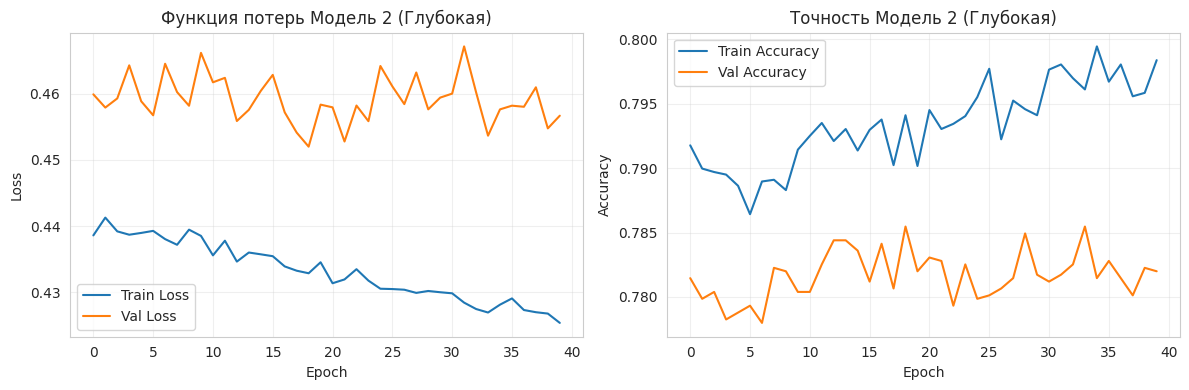

In [ ]:
#Визуализация
plot_training_history(history2, "Модель 2 (Глубокая)")


================================================================================
МОДЕЛЬ 3: СЕТЬ С TANH АКТИВАЦИЕЙ
================================================================================
Архитектура: 32-16-8-1, Tanh, Adam, Dropout=0.1, 35 эпох

In [ ]:
# Создание модели 3
model3 = Sequential()
model3.add(Dense(32, activation='tanh', input_shape=(X_train_scaled.shape[1],)))
model3.add(Dropout(0.1))
model3.add(Dense(16, activation='tanh'))
model3.add(Dropout(0.1))
model3.add(Dense(8, activation='tanh'))
model3.add(Dense(1, activation='sigmoid'))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Компиляция
model3.compile(optimizer=Adam(learning_rate=0.001),
               loss='binary_crossentropy',
               metrics=['accuracy'])

In [ ]:
# Обучение
history3 = model3.fit(X_train_scaled, y_train,
                      epochs=35,
                      batch_size=32,
                      verbose=1,
                      validation_data=(X_test_scaled, y_test))


Epoch 1/35
468/468 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.6944 - loss: 0.5695 - val_accuracy: 0.7609 - val_loss: 0.4801
Epoch 2/35
468/468 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7788 - loss: 0.4649 - val_accuracy: 0.7702 - val_loss: 0.4728
Epoch 3/35
468/468 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7800 - loss: 0.4538 - val_accuracy: 0.7724 - val_loss: 0.4695
Epoch 4/35
468/468 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7766 - loss: 0.4547 - val_accuracy: 0.7716 - val_loss: 0.4655
Epoch 5/35
468/468 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7794 - loss: 0.4535 - val_accuracy: 0.7718 - val_loss: 0.4646
Epoch 6/35
468/468 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7849 - loss: 0.4441 - val_accuracy: 0.7753 - val_loss: 0.4623
Epoch 7/35
468/468 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7720 - loss: 0.4560 - val_accuracy: 0.7740 - val_loss: 0.4624
Epoch 8/35
468/468 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7772 - loss: 0.4518 - val_accuracy: 

In [ ]:
# Оценка
metrics3 = evaluate_model(model3, X_test_scaled, y_test, "Модель 3 (Tanh)")


Accuracy: 0.7766
Precision: 0.5564
Recall: 0.4844
F1-Score: 0.5179

Отчет по классификации для Модель 3 (Tanh):
              precision    recall  f1-score   support

     Class 0       0.84      0.87      0.85      2816
     Class 1       0.56      0.48      0.52       927

    accuracy                           0.78      3743
   macro avg       0.70      0.68      0.69      3743
weighted avg       0.77      0.78      0.77      3743



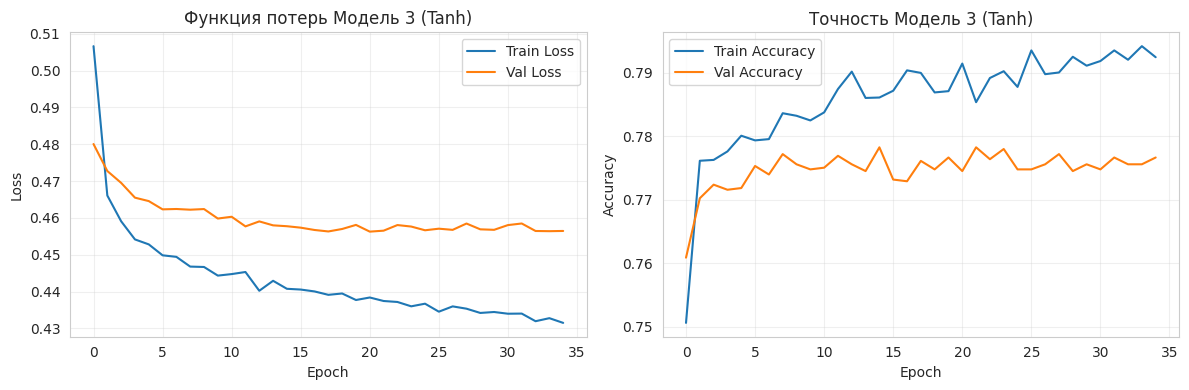

In [ ]:
# Визуализация
plot_training_history(history3, "Модель 3 (Tanh)")

================================================================================
МОДЕЛЬ 4: СЕТЬ С SGD ОПТИМИЗАТОРОМ
================================================================================
Архитектура: 32-16-8-1, ReLU, SGD с моментом, 50 эпох

In [ ]:
# Создание модели 4
model4 = Sequential()
model4.add(Dense(32, activation='relu', input_shape=(X_train_scaled.shape[1],)))
model4.add(Dense(16, activation='relu'))
model4.add(Dense(8, activation='relu'))
model4.add(Dense(1, activation='sigmoid'))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Компиляция с SGD
model4.compile(optimizer=SGD(learning_rate=0.01, momentum=0.9),
               loss='binary_crossentropy',
               metrics=['accuracy'])

In [ ]:
# Обучение
history4 = model4.fit(X_train_scaled, y_train,
                      epochs=50,
                      batch_size=16,
                      verbose=1,
                      validation_data=(X_test_scaled, y_test))

Epoch 1/50
936/936 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.7530 - loss: 0.5036 - val_accuracy: 0.7689 - val_loss: 0.4716
Epoch 2/50
936/936 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.7811 - loss: 0.4556 - val_accuracy: 0.7758 - val_loss: 0.4685
Epoch 3/50
936/936 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.7870 - loss: 0.4446 - val_accuracy: 0.7758 - val_loss: 0.4617
Epoch 4/50
936/936 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7877 - loss: 0.4416 - val_accuracy: 0.7788 - val_loss: 0.4601
Epoch 5/50
936/936 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7924 - loss: 0.4393 - val_accuracy: 0.7772 - val_loss: 0.4564
Epoch 6/50
936/936 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7903 - loss: 0.4309 - val_accuracy: 0.7758 - val_loss: 0.4594
Epoch 7/50
936/936 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7877 - loss: 0.4407 - val_accuracy: 0.7817 - val_loss: 0.4611
Epoch 8/50
936/936 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7887 - loss: 0.4406 - val_accuracy: 0.

In [ ]:
# Оценка
metrics4 = evaluate_model(model4, X_test_scaled, y_test, "Модель 4 (SGD)")


Accuracy: 0.7678
Precision: 0.5490
Recall: 0.3506
F1-Score: 0.4279

Отчет по классификации для Модель 4 (SGD):
              precision    recall  f1-score   support

     Class 0       0.81      0.91      0.85      2816
     Class 1       0.55      0.35      0.43       927

    accuracy                           0.77      3743
   macro avg       0.68      0.63      0.64      3743
weighted avg       0.74      0.77      0.75      3743



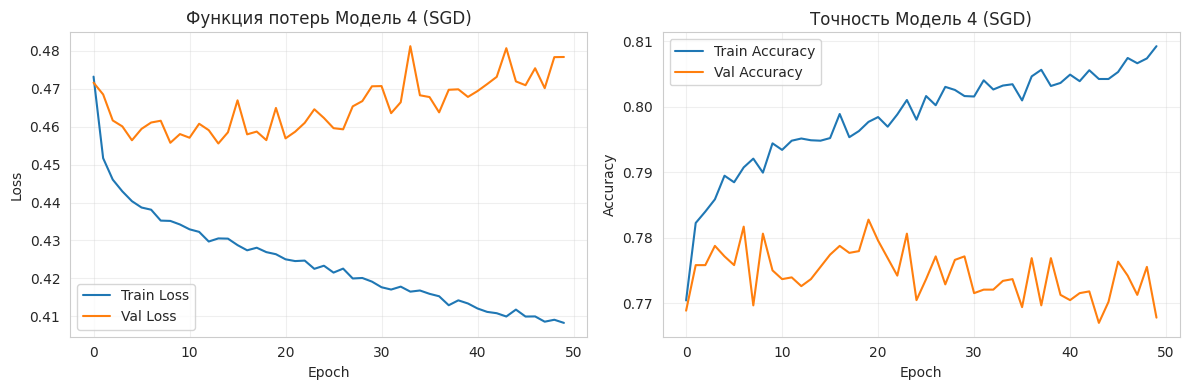

In [ ]:
# Визуализация
plot_training_history(history4, "Модель 4 (SGD)")



================================================================================
МОДЕЛЬ 5: БОЛЬШАЯ СЕТЬ С РЕГУЛЯРИЗАЦИЕЙ
================================================================================
Архитектура: 128-64-32-16-8-1, ReLU, Adam, Dropout=0.3, L2=0.001, 60 эпох

In [ ]:
# Создание модели 5
model5 = Sequential()
model5.add(Dense(128, activation='relu',
                 kernel_regularizer=l2(0.001),
                 input_shape=(X_train_scaled.shape[1],)))
model5.add(Dropout(0.3))
model5.add(Dense(64, activation='relu', kernel_regularizer=l2(0.001)))
model5.add(Dropout(0.3))
model5.add(Dense(32, activation='relu', kernel_regularizer=l2(0.001)))
model5.add(Dropout(0.3))
model5.add(Dense(16, activation='relu'))
model5.add(Dropout(0.3))
model5.add(Dense(8, activation='relu'))
model5.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Компиляция
model5.compile(optimizer=Adam(learning_rate=0.0005),
               loss='binary_crossentropy',
               metrics=['accuracy'])

In [ ]:
# Обучение
history5 = model5.fit(X_train_scaled, y_train,
                      epochs=60,
                      batch_size=128,
                      verbose=1,
                      validation_data=(X_test_scaled, y_test))

Epoch 1/60
117/117 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.7328 - loss: 0.7497 - val_accuracy: 0.7523 - val_loss: 0.6568
Epoch 2/60
117/117 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.7549 - loss: 0.6677 - val_accuracy: 0.7641 - val_loss: 0.6259
Epoch 3/60
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7642 - loss: 0.6292 - val_accuracy: 0.7734 - val_loss: 0.6055
Epoch 4/60
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7637 - loss: 0.6067 - val_accuracy: 0.7758 - val_loss: 0.5897
Epoch 5/60
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7654 - loss: 0.6026 - val_accuracy: 0.7745 - val_loss: 0.5737
Epoch 6/60
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7620 - loss: 0.5837 - val_accuracy: 0.7761 - val_loss: 0.5608
Epoch 7/60
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7659 - loss: 0.5644 - val_accuracy: 0.7780 - val_loss: 0.5512
Epoch 8/60
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7746 - loss: 0.5430 - val_accuracy:

In [ ]:
# Оценка
metrics5 = evaluate_model(model5, X_test_scaled, y_test, "Модель 5 (Большая с регуляризацией)")

Accuracy: 0.7815
Precision: 0.5529
Recall: 0.6149
F1-Score: 0.5822

Отчет по классификации для Модель 5 (Большая с регуляризацией):
              precision    recall  f1-score   support

     Class 0       0.87      0.84      0.85      2816
     Class 1       0.55      0.61      0.58       927

    accuracy                           0.78      3743
   macro avg       0.71      0.73      0.72      3743
weighted avg       0.79      0.78      0.79      3743



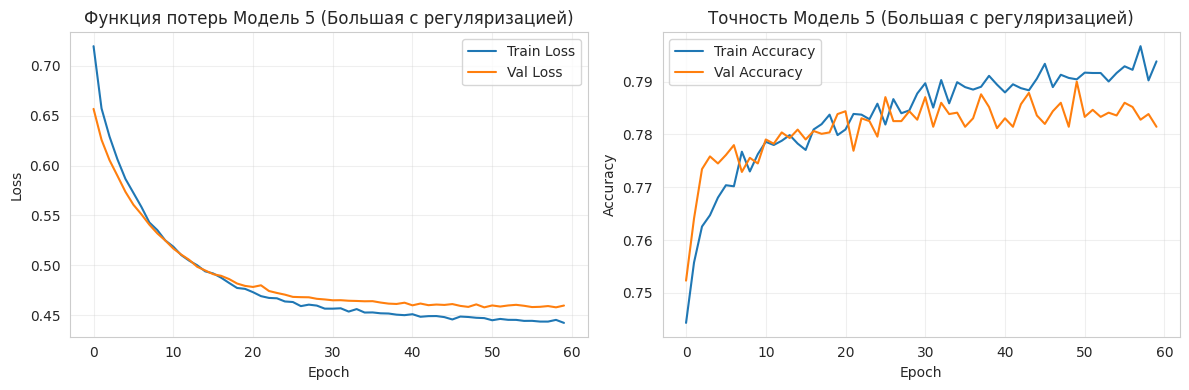

In [ ]:
# Визуализация
plot_training_history(history5, "Модель 5 (Большая с регуляризацией)")



================================================================================
МОДЕЛЬ 6: КОМПАКТНАЯ БЫСТРАЯ СЕТЬ
================================================================================
Архитектура: 16-8-1, ReLU, Adam, 25 эпох

In [ ]:
# Создание модели 6
model6 = Sequential()
model6.add(Dense(16, activation='relu', input_shape=(X_train_scaled.shape[1],)))
model6.add(Dense(8, activation='relu'))
model6.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Компиляция
model6.compile(optimizer=Adam(learning_rate=0.002),
               loss='binary_crossentropy',
               metrics=['accuracy'])

In [ ]:
# Обучение
history6 = model6.fit(X_train_scaled, y_train,
                      epochs=25,
                      batch_size=16,
                      verbose=1,
                      validation_data=(X_test_scaled, y_test))

Epoch 1/25
936/936 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.7263 - loss: 0.5230 - val_accuracy: 0.7726 - val_loss: 0.4792
Epoch 2/25
936/936 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.7812 - loss: 0.4541 - val_accuracy: 0.7761 - val_loss: 0.4673
Epoch 3/25
936/936 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7866 - loss: 0.4514 - val_accuracy: 0.7724 - val_loss: 0.4634
Epoch 4/25
936/936 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7867 - loss: 0.4443 - val_accuracy: 0.7772 - val_loss: 0.4641
Epoch 5/25
936/936 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7928 - loss: 0.4403 - val_accuracy: 0.7750 - val_loss: 0.4615
Epoch 6/25
936/936 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7962 - loss: 0.4372 - val_accuracy: 0.7777 - val_loss: 0.4630
Epoch 7/25
936/936 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7980 - loss: 0.4322 - val_accuracy: 0.7721 - val_loss: 0.4603
Epoch 8/25
936/936 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7870 - loss: 0.4429 - val_accuracy: 0.

In [ ]:
# Оценка
metrics6 = evaluate_model(model6, X_test_scaled, y_test, "Модель 6 (Компактная)")

Accuracy: 0.7793
Precision: 0.5660
Recall: 0.4671
F1-Score: 0.5118

Отчет по классификации для Модель 6 (Компактная):
              precision    recall  f1-score   support

     Class 0       0.83      0.88      0.86      2816
     Class 1       0.57      0.47      0.51       927

    accuracy                           0.78      3743
   macro avg       0.70      0.67      0.68      3743
weighted avg       0.77      0.78      0.77      3743



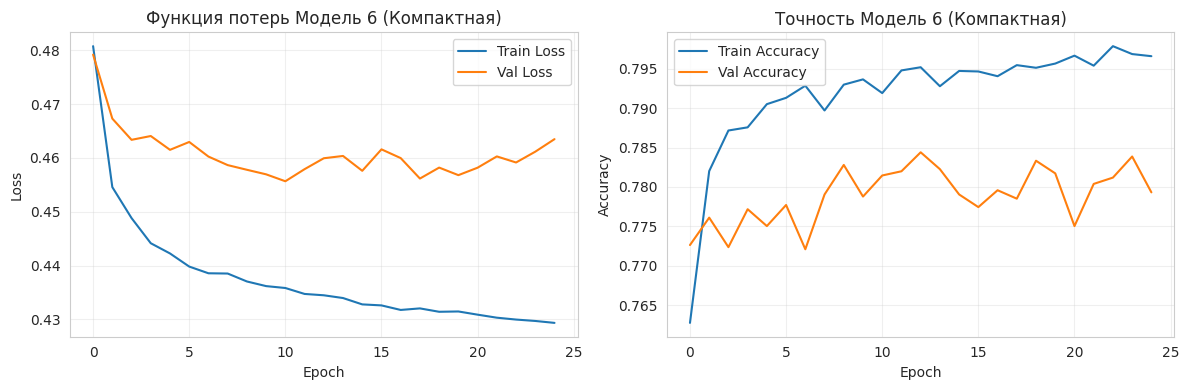

In [ ]:
# Визуализация
plot_training_history(history6, "Модель 6 (Компактная)")



================================================================================
МОДЕЛЬ 7: СЕТЬ С RMSPROP ОПТИМИЗАТОРОМ
================================================================================
Архитектура: 48-24-12-1, ReLU, RMSprop, Dropout=0.15, 45 эпох

In [ ]:
# Создание модели 7
model7 = Sequential()
model7.add(Dense(48, activation='relu', input_shape=(X_train_scaled.shape[1],)))
model7.add(Dropout(0.15))
model7.add(Dense(24, activation='relu'))
model7.add(Dropout(0.15))
model7.add(Dense(12, activation='relu'))
model7.add(Dense(1, activation='sigmoid'))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Компиляция с RMSprop
model7.compile(optimizer=RMSprop(learning_rate=0.0005),
               loss='binary_crossentropy',
               metrics=['accuracy'])

In [ ]:
# Обучение
history7 = model7.fit(X_train_scaled, y_train,
                      epochs=45,
                      batch_size=48,
                      verbose=1,
                      validation_data=(X_test_scaled, y_test))

Epoch 1/45
312/312 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.6657 - loss: 0.6100 - val_accuracy: 0.7646 - val_loss: 0.4821
Epoch 2/45
312/312 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7715 - loss: 0.4760 - val_accuracy: 0.7684 - val_loss: 0.4753
Epoch 3/45
312/312 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7717 - loss: 0.4721 - val_accuracy: 0.7721 - val_loss: 0.4710
Epoch 4/45
312/312 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7823 - loss: 0.4617 - val_accuracy: 0.7734 - val_loss: 0.4692
Epoch 5/45
312/312 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7813 - loss: 0.4592 - val_accuracy: 0.7766 - val_loss: 0.4664
Epoch 6/45
312/312 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7904 - loss: 0.4509 - val_accuracy: 0.7750 - val_loss: 0.4647
Epoch 7/45
312/312 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7862 - loss: 0.4546 - val_accuracy: 0.7783 - val_loss: 0.4633
Epoch 8/45
312/312 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7854 - loss: 0.4508 - val_accuracy: 0.

In [ ]:
# Оценка
metrics7 = evaluate_model(model7, X_test_scaled, y_test, "Модель 7 (RMSprop)")

Accuracy: 0.7831
Precision: 0.5656
Recall: 0.5351
F1-Score: 0.5499

Отчет по классификации для Модель 7 (RMSprop):
              precision    recall  f1-score   support

     Class 0       0.85      0.86      0.86      2816
     Class 1       0.57      0.54      0.55       927

    accuracy                           0.78      3743
   macro avg       0.71      0.70      0.70      3743
weighted avg       0.78      0.78      0.78      3743



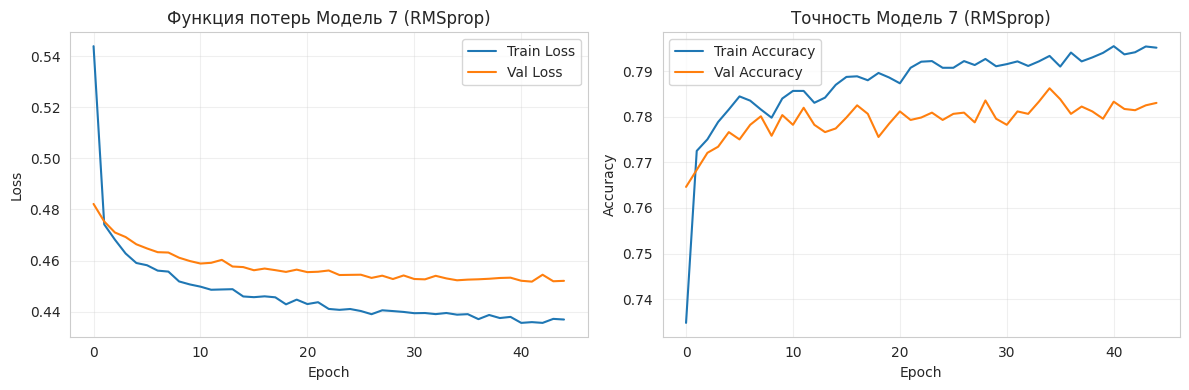

In [ ]:
# Визуализация
plot_training_history(history7, "Модель 7 (RMSprop)")



================================================================================
МОДЕЛЬ 8: СЕТЬ С LEAKYRELU АКТИВАЦИЕЙ
================================================================================
Архитектура: 32-16-8-1, LeakyReLU (alpha=0.1), Adam, Dropout=0.2, 30 эпох

In [ ]:
# Создание модели 8 с LeakyReLU
model8 = Sequential()
# Первый слой с LeakyReLU
model8.add(Dense(32, input_shape=(X_train_scaled.shape[1],)))
model8.add(LeakyReLU(alpha=0.1))  # alpha - наклон для отрицательных значений
model8.add(Dropout(0.2))
# Второй слой с LeakyReLU
model8.add(Dense(16))
model8.add(LeakyReLU(alpha=0.1))
model8.add(Dropout(0.2))

# Третий слой с LeakyReLU
model8.add(Dense(8))
model8.add(LeakyReLU(alpha=0.1))

# Выходной слой
model8.add(Dense(1, activation='sigmoid'))


In [ ]:
# Компиляция
model8.compile(optimizer=Adam(learning_rate=0.001),
               loss='binary_crossentropy',
               metrics=['accuracy'])

In [ ]:
# Обучение
history8 = model8.fit(X_train_scaled, y_train,
                      epochs=30,
                      batch_size=32,
                      verbose=1,
                      validation_data=(X_test_scaled, y_test))


Epoch 1/30
468/468 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.7535 - loss: 0.5396 - val_accuracy: 0.7710 - val_loss: 0.4784
Epoch 2/30
468/468 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7693 - loss: 0.4815 - val_accuracy: 0.7772 - val_loss: 0.4714
Epoch 3/30
468/468 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7753 - loss: 0.4622 - val_accuracy: 0.7772 - val_loss: 0.4709
Epoch 4/30
468/468 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7859 - loss: 0.4601 - val_accuracy: 0.7716 - val_loss: 0.4680
Epoch 5/30
468/468 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.7801 - loss: 0.4596 - val_accuracy: 0.7783 - val_loss: 0.4659
Epoch 6/30
468/468 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.7817 - loss: 0.4555 - val_accuracy: 0.7785 - val_loss: 0.4648
Epoch 7/30
468/468 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.7859 - loss: 0.4517 - val_accuracy: 0.7785 - val_loss: 0.4641
Epoch 8/30
468/468 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7822 - loss: 0.4497 - val_accuracy:

In [ ]:
# Оценка
metrics8 = evaluate_model(model8, X_test_scaled, y_test, "Модель 8 (LeakyReLU)")

Accuracy: 0.7804
Precision: 0.5569
Recall: 0.5545
F1-Score: 0.5557

Отчет по классификации для Модель 8 (LeakyReLU):
              precision    recall  f1-score   support

     Class 0       0.85      0.85      0.85      2816
     Class 1       0.56      0.55      0.56       927

    accuracy                           0.78      3743
   macro avg       0.71      0.70      0.70      3743
weighted avg       0.78      0.78      0.78      3743



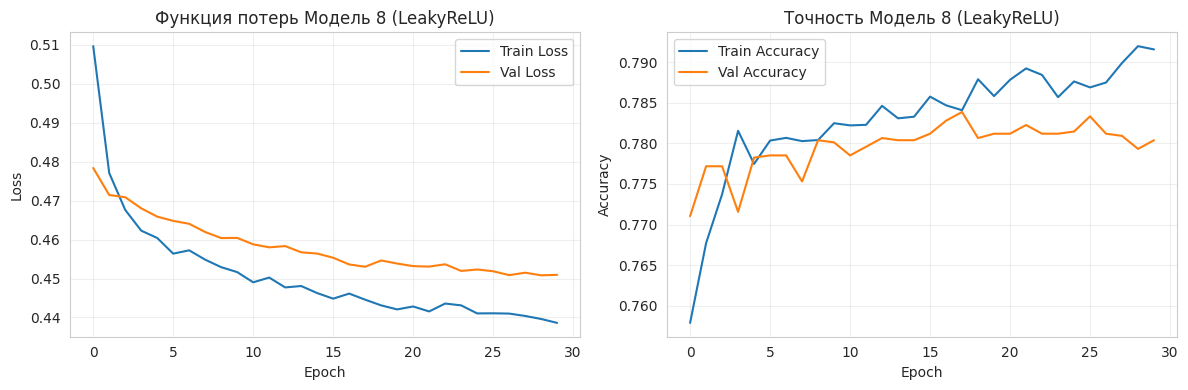

In [ ]:
# Визуализация
plot_training_history(history8, "Модель 8 (LeakyReLU)")


In [ ]:
# Создаем сводную таблицу
results_summary = pd.DataFrame({
    'Модель': [
        '1. Базовая (20-10-1, ReLU, Adam)',
        '2. Глубокая (64-32-16-8-1, ReLU, Adam, Dropout)',
        '3. Tanh (32-16-8-1, Tanh, Adam, Dropout)',
        '4. SGD (32-16-8-1, ReLU, SGD с моментом)',
        '5. Большая с регуляризацией (128-64-32-16-8-1, ReLU, Adam, L2+Dropout)',
        '6. Компактная (16-8-1, ReLU, Adam)',
        '7. RMSprop (48-24-12-1, ReLU, RMSprop, Dropout)',
        '8. LeakyReLU (32-16-8-1, LeakyReLU, Adam, Dropout)'  # Новая модель
    ],
    'Активация': [
        'ReLU', 'ReLU', 'Tanh', 'ReLU', 'ReLU', 'ReLU', 'ReLU', 'LeakyReLU'
    ],
    'Оптимизатор': [
        'Adam', 'Adam', 'Adam', 'SGD', 'Adam', 'Adam', 'RMSprop', 'Adam'
    ],
    'Accuracy': [
        metrics1['accuracy'],
        metrics2['accuracy'],
        metrics3['accuracy'],
        metrics4['accuracy'],
        metrics5['accuracy'],
        metrics6['accuracy'],
        metrics7['accuracy'],
        metrics8['accuracy']
    ],
    'F1-Score': [
        metrics1['f1'],
        metrics2['f1'],
        metrics3['f1'],
        metrics4['f1'],
        metrics5['f1'],
        metrics6['f1'],
        metrics7['f1'],
        metrics8['f1']
    ],
    'Precision': [
        metrics1['precision'],
        metrics2['precision'],
        metrics3['precision'],
        metrics4['precision'],
        metrics5['precision'],
        metrics6['precision'],
        metrics7['precision'],
        metrics8['precision']
    ],
    'Recall': [
        metrics1['recall'],
        metrics2['recall'],
        metrics3['recall'],
        metrics4['recall'],
        metrics5['recall'],
        metrics6['recall'],
        metrics7['recall'],
        metrics8['recall']
    ],
    'Параметры (тыс.)': [
        model.count_params() / 1000,
        model2.count_params() / 1000,
        model3.count_params() / 1000,
        model4.count_params() / 1000,
        model5.count_params() / 1000,
        model6.count_params() / 1000,
        model7.count_params() / 1000,
        model8.count_params() / 1000
    ]
})

In [ ]:
# Сортируем по Accuracy
results_summary_sorted = results_summary.sort_values('Accuracy', ascending=False).reset_index(drop=True)
results_summary_sorted.index += 1

In [ ]:
# Выводим таблицу
pd.set_option('display.float_format', '{:.4f}'.format)
print("\nРезультаты всех моделей (сортировка по Accuracy):")
print(results_summary_sorted[['Модель', 'Активация', 'Оптимизатор', 'Accuracy', 'F1-Score']].to_string())


Результаты всех моделей (сортировка по Accuracy):
                                                                   Модель  Активация Оптимизатор  Accuracy  F1-Score
1                         7. RMSprop (48-24-12-1, ReLU, RMSprop, Dropout)       ReLU     RMSprop    0.7831    0.5499
2                         2. Глубокая (64-32-16-8-1, ReLU, Adam, Dropout)       ReLU        Adam    0.7820    0.5714
3  5. Большая с регуляризацией (128-64-32-16-8-1, ReLU, Adam, L2+Dropout)       ReLU        Adam    0.7815    0.5822
4                      8. LeakyReLU (32-16-8-1, LeakyReLU, Adam, Dropout)  LeakyReLU        Adam    0.7804    0.5557
5                                      6. Компактная (16-8-1, ReLU, Adam)       ReLU        Adam    0.7793    0.5118
6                                        1. Базовая (20-10-1, ReLU, Adam)       ReLU        Adam    0.7788    0.5147
7                                3. Tanh (32-16-8-1, Tanh, Adam, Dropout)       Tanh        Adam    0.7766    0.5179
8            

In [ ]:
# Визуализация сравнения моделей
plt.figure(figsize=(16, 12))

<Figure size 1600x1200 with 0 Axes>

<Figure size 1600x1200 with 0 Axes>

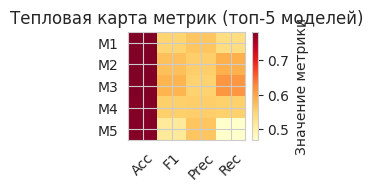

In [ ]:
# 7. Тепловая карта метрик для топ-5 моделей
plt.subplot(3, 3, 7)
top_5 = results_summary_sorted.head(5)
metrics_heatmap = top_5[['Accuracy', 'F1-Score', 'Precision', 'Recall']].values
im = plt.imshow(metrics_heatmap, cmap='YlOrRd', aspect='auto')
plt.title('Тепловая карта метрик (топ-5 моделей)')
plt.xticks(range(4), ['Acc', 'F1', 'Prec', 'Rec'], rotation=45)
plt.yticks(range(5), [f"M{i}" for i in top_5.index])
plt.colorbar(im, label='Значение метрики')

In [ ]:
print(f"\n2. РЕЙТИНГ МОДЕЛЕЙ:")
for i, row in results_summary_sorted.iterrows():
    place = f"{i} место" if i == 1 else f"{i} место"
    print(f"   {place}: {row['Модель']} (Accuracy: {row['Accuracy']:.4f})")

print(f"\n3. АНАЛИЗ ФУНКЦИЙ АКТИВАЦИИ:")
for activation in results_summary['Активация'].unique():
    activation_data = results_summary[results_summary['Активация'] == activation]
    print(f"   • {activation}:")
    print(f"     - Средний Accuracy: {activation_data['Accuracy'].mean():.4f}")
    print(f"     - Лучшая Accuracy: {activation_data['Accuracy'].max():.4f}")
    print(f"     - Количество моделей: {len(activation_data)}")

print(f"\n4. РЕКОМЕНДАЦИИ ПО ВЫБОРУ АКТИВАЦИИ:")
print(f"   • LeakyReLU лучше ReLU, если есть проблема 'умирающих нейронов'")
print(f"   • ReLU обычно быстрее и проще")
print(f"   • Tanh хорошо работает в RNN/LSTM, но может быть медленнее")
print(f"   • Для вашей задачи лучшая активация: {best_activation}")

print(f"\n5. СТАТИСТИКА ПО ВСЕМ МОДЕЛЯМ:")
print(f"   • Средний Accuracy: {results_summary_sorted['Accuracy'].mean():.4f}")
print(f"   • Максимальный Accuracy: {results_summary_sorted['Accuracy'].max():.4f}")
print(f"   • Минимальный Accuracy: {results_summary_sorted['Accuracy'].min():.4f}")
print(f"   • Разница лучшей/худшей: {(results_summary_sorted['Accuracy'].max() - results_summary_sorted['Accuracy'].min())*100:.2f}%")
print(f"   • Лучшая функция активации: {best_activation}")




2. РЕЙТИНГ МОДЕЛЕЙ:
   1 место: 7. RMSprop (48-24-12-1, ReLU, RMSprop, Dropout) (Accuracy: 0.7831)
   2 место: 2. Глубокая (64-32-16-8-1, ReLU, Adam, Dropout) (Accuracy: 0.7820)
   3 место: 5. Большая с регуляризацией (128-64-32-16-8-1, ReLU, Adam, L2+Dropout) (Accuracy: 0.7815)
   4 место: 8. LeakyReLU (32-16-8-1, LeakyReLU, Adam, Dropout) (Accuracy: 0.7804)
   5 место: 6. Компактная (16-8-1, ReLU, Adam) (Accuracy: 0.7793)
   6 место: 1. Базовая (20-10-1, ReLU, Adam) (Accuracy: 0.7788)
   7 место: 3. Tanh (32-16-8-1, Tanh, Adam, Dropout) (Accuracy: 0.7766)
   8 место: 4. SGD (32-16-8-1, ReLU, SGD с моментом) (Accuracy: 0.7678)

3. АНАЛИЗ ФУНКЦИЙ АКТИВАЦИИ:
   • ReLU:
     - Средний Accuracy: 0.7787
     - Лучшая Accuracy: 0.7831
     - Количество моделей: 6
   • Tanh:
     - Средний Accuracy: 0.7766
     - Лучшая Accuracy: 0.7766
     - Количество моделей: 1
   • LeakyReLU:
     - Средний Accuracy: 0.7804
     - Лучшая Accuracy: 0.7804
     - Количество моделей: 1

4. РЕКОМЕНДАЦИИ ПО

In [ ]:
## Анализ лучшей модели
best_model_idx = results_summary_sorted.iloc[0].name - 1
best_model_name = results_summary_sorted.iloc[0]['Модель']
best_accuracy = results_summary_sorted.iloc[0]['Accuracy']
best_f1 = results_summary_sorted.iloc[0]['F1-Score']
best_activation = results_summary_sorted.iloc[0]['Активация']

print(f"\n1. ЛУЧШАЯ МОДЕЛЬ: {best_model_name}")
print(f"   • Accuracy: {best_accuracy:.4f}")
print(f"   • F1-Score: {best_f1:.4f}")
print(f"   • Функция активации: {best_activation}")

# Определяем лучшую модель по номеру
best_models_dict = {
    1: "Модель 1 (Базовая)",
    2: "Модель 2 (Глубокая)",
    3: "Модель 3 (Tanh)",
    4: "Модель 4 (SGD)",
    5: "Модель 5 (Большая с регуляризацией)",
    6: "Модель 6 (Компактная)",
    7: "Модель 7 (RMSprop)",
    8: "Модель 8 (LeakyReLU)"
}



1. ЛУЧШАЯ МОДЕЛЬ: 7. RMSprop (48-24-12-1, ReLU, RMSprop, Dropout)
   • Accuracy: 0.7831
   • F1-Score: 0.5499
   • Функция активации: ReLU
